In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import os
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


from tp7.tp7 import Tape7
from srfs.srfs import SRFS
from matt_code.convert_tp7 import load_all_runs_from_tp7
import scipy.integrate as integrate
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, explained_variance_score, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.tree import export_text, plot_tree
np.random.seed(42)


import warnings
warnings.filterwarnings('ignore')
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

a00_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA85")

srf = SRFS("./data/libera_srfs_20241017.csv")
tot_wvln = srf.srf_vals['wavelength [um]']
sw_srf = srf.srf_vals[' sw srf']
lw_srf = srf.srf_vals[' lw srf']
srf_path = "./data/srf/"
# tot_wvln = srf.srf_vals['wavelength_um']
# sw_srf = srf.srf_vals['sw_srf']
# lw_srf = srf.srf_vals['lw_srf']

viirs_rads_indxs = {'M1': [1469, 1701],
             'M2': [1648, 1849],
             'M3': [1873, 2039],
             'M4': [2131, 2260],
             'I1': [2231, 2601],
             'M5': [2467, 2559],
             'DNB': [667, 3090],
             'M6': [2621, 2696],
             'I2': [2790, 2893],
             'M7': [2790, 2893],
             'M8': [3181, 3206],
             'M9': [3264, 3284],
             'I3': [3355, 3401],
             'M10': [3355, 3401],
             'M11': [3546, 3565],
             'I4': [3703, 3757],
             'M12': [3716, 3742],
             'M13': [3744, 3762],
             'M14': [3879, 3887],
             'M15': [3898, 3914],
             'I5': [3896, 3925],
             'M16': [3910, 3922]}

viirs_band_ranges = {
    "I1": "I1 0.60 - 0.68 μm",
    "I2": "I2 0.85 - 0.88 μm",
    "I3": "I3 1.58 - 1.64 μm",
    "I4": "I4 3.55 - 3.93 μm",
    "I5": "I5 10.5 - 12.4 μm",
    "M1": "M1 0.402 - 0.422 μm",
    "M2": "M2 0.436 - 0.454 μm",
    "M3": "M3 0.478 - 0.488 μm",
    "M4": "M4 0.545 - 0.565 μm",
    "M5": "M5 0.662 - 0.682 μm",
    "M6": "M6 0.739 - 0.754 μm",
    "M7": "M7 0.846 - 0.885 μm",
    "M8": "M8 1.23 - 1.25 μm",
    "M9": "M9 1.371 - 1.386 μm",
    "M10": "M10 1.58 - 1.64 μm",
    "M11": "M11 2.23 - 2.28 μm",
    "M12": "M11 3.61 - 3.79 μm",
    "M13": "M13 3.97 - 4.13 μm",
    "M14": "M14 8.4 - 8.7 μm",
    "M15": "M15 10.26 - 11.26 μm",
    "M16": "M16 11.54 - 12.49 μm",
    "DNB": "DNB 0.50 - 0.90 μm"
}

def rename_bands(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns=viirs_band_ranges)
def plot_radiance(rads, title, runnum, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(rads[runnum, 0, :], rads[runnum, s_or_l, :] * 1e6, 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 2:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)


def plot_integrated_radiance(rads, title, idx, wvs, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(wvs, rads[idx, :], 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 1:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)


y_lim_map = {
    "Snow": [[1.75e-6, 4], [1e-5, 100]],
    "Cloudy Ocean": [[2.25e-6, 5], [1e-5, 100]],
    "Land": [[600, 3], [10, 50]],
    "Clear Ocean": [[7e-7, 3], [1.75e-5, 100]],
    "Deep Convective Cloud": [[500, 3], [2.5, 80]]
}

def plot_sza(sza_dict: dict):
    fig, axes = plt.subplots(5, 1, figsize=(18, 50))

    for i, (key, tp7) in enumerate(sza_dict.items()):

        wavelength = tp7.rads[0, 0, :]

        print(key)
        ax_sw = axes[i]
        shortwave = tp7.rads[-1, 1, :]
        interp_shortwave_filt = np.interp(x=wavelength, xp=tot_wvln, fp=sw_srf)
        shortwave_filt = interp_shortwave_filt * shortwave

        ax_sw.plot(wavelength, shortwave_filt, 'r-', label='Filtered')
        ax_sw.plot(wavelength, shortwave, 'b-', label='Unfiltered')
        # ax_sw.set_xlim(0, y_lim_map[key][0][1])
        # ax_sw.set_ylim(0, y_lim_map[key][0][0])
        ax_sw.set_xlim(0, y_lim_map["Land"][0][1])
        ax_sw.set_ylim(0, y_lim_map["Land"][0][0])

        ax_sw.legend(prop={"size": 10})
        ax_sw.set_title(f'Shortwave: {key}')
        ax_sw.set_ylabel('Radiance Wm$^{-2}$µm$^{-1}$sr$^{-1}$')
        ax_sw.set_xlabel('Wavelength µm')
        ax_sw.grid(True)


        # ax_lw = axes[i, 1]
        # longwave = tp7.rads[-1, 2, :]
        # longwave_filt = np.interp(x=wavelength, xp=tot_wvln, fp=lw_srf)
        # longwave_filt = longwave_filt * shortwave
        # ax_lw.plot(wavelength, longwave, longwave_filt, 'b-', label='Longwave')
        # ax_lw.set_xlim(5, y_lim_map[key][1][1])
        # ax_lw.set_ylim(0, y_lim_map[key][1][0])
        #
        # ax_lw.legend(prop={"size": 10})
        # ax_lw.set_title(f'Longwave: {key}')
        # ax_lw.set_ylabel('Radiance Wm$^{-2}$µm$^{-1}$sr$^{-1}$')
        # ax_lw.set_xlabel('Wavelength µm')
        # ax_lw.grid(True)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4)
    plt.show()


viirs_rads_indxs = {'M1': [1469, 1701],
             'M2': [1648, 1849],
             'M3': [1873, 2039],
             'M4': [2131, 2260],
             'I1': [2231, 2601],
             'M5': [2467, 2559],
             'DNB': [667, 3090],
             'M6': [2621, 2696],
             'I2': [2790, 2893],
             'M7': [2790, 2893],
             'M8': [3181, 3206],
             'M9': [3264, 3284],
             'I3': [3355, 3401],
             'M10': [3355, 3401],
             'M11': [3546, 3565],
             'I4': [3703, 3757],
             'M12': [3716, 3742],
             'M13': [3744, 3762],
             'M14': [3879, 3887],
             'M15': [3898, 3914],
             'I5': [3896, 3925],
             'M16': [3910, 3922]}

def viirs_band_integration(tp7_data: Tape7, rad_indxs: dict):
    for idx, run in enumerate(tp7_data.rads):
        for band, rng in rad_indxs.items():
            y_vals = run[1][rng[0]: rng[1] + 1]
            x_vals = run[0][rng[0]: rng[1] + 1]
            integrated = integrate.simpson(y=y_vals, x=x_vals)
            tp7_data.describer_df.loc[idx, band] = integrated


a00_data = [Tape7(file, srf_path) for file in a00_files]
titles = [file.title for file in a00_data]
a00 = {title: file for title, file in zip(titles, a00_data)}

a41_data = [Tape7(file, srf_path) for file in a41_files]
titles = [file.title for file in a41_data]
a41 = {title: file for title, file in zip(titles, a41_data)}

a60_data = [Tape7(file, srf_path) for file in a60_files]
titles = [file.title for file in a60_data]
a60 = {title: file for title, file in zip(titles, a60_data)}

a75_data = [Tape7(file, srf_path) for file in a75_files]
titles = [file.title for file in a75_data]
a75 = {title: file for title, file in zip(titles, a75_data)}

a85_data = [Tape7(file, srf_path) for file in a85_files]
titles = [file.title for file in a85_data]
a85 = {title: file for title, file in zip(titles, a85_data)}


snow_data = [a00["Snow"], a41["Snow"], a60["Snow"], a75["Snow"], a85["Snow"]]
dc_data = [a00["Deep Convective Cloud"], a41["Deep Convective Cloud"], a60["Deep Convective Cloud"],
           a75["Deep Convective Cloud"], a85["Deep Convective Cloud"]]
land_data = [a00["Land"], a41["Land"], a60["Land"], a75["Land"], a85["Land"]]
clear_data = [a00["Clear Ocean"], a41["Clear Ocean"], a60["Clear Ocean"], a75["Clear Ocean"], a85["Clear Ocean"]]
cloudy_data = [a00["Cloudy Ocean"], a41["Cloudy Ocean"], a60["Cloudy Ocean"], a75["Cloudy Ocean"], a85["Cloudy Ocean"]]
[viirs_band_integration(data, viirs_rads_indxs) for data in snow_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in dc_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in land_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in clear_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in cloudy_data]

all_tp7_objects = [snow_data, land_data, cloudy_data, clear_data, dc_data]

snow_dfs = [file.describer_df for file in snow_data]
snow_dataset = pd.concat(snow_dfs, axis=0)
land_dfs = [file.describer_df for file in land_data]
dc_dfs = [file.describer_df for file in dc_data]
cloud_dfs = [file.describer_df for file in cloudy_data]
clear_dfs = [file.describer_df for file in clear_data]
land_dataset = pd.concat(land_dfs, axis=0)
dc_dataset = pd.concat(dc_dfs, axis=0)
cloud_dataset = pd.concat(cloud_dfs, axis=0)
clear_dataset = pd.concat(clear_dfs, axis=0)
all_dataset = pd.concat([snow_dataset, land_dataset, dc_dataset, cloud_dataset, clear_dataset])

def run_regression_model(dataset: pd.DataFrame, neurons=100, rf = True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    # in the X dataset we want everything except the Unfiltered ground truth data and the run # and Scene
    X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)","Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",]).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    print(X.columns, y.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    if rf:
        base_model = RandomForestRegressor(n_estimators=neurons, random_state=42)
    else:
        base_model = LinearRegression()
    regression_model = MultiOutputRegressor(base_model)
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
    rmse = root_mean_squared_error(y_test, y_pred, multioutput='raw_values')
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Single MSE"] = mse
    ret["RMSE"] = rmse
    ret["MAE"] = mae
    ret["MAEP"] = mae_percentage

    tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    ret["Shortwave MSPE"] = (1.0 - (rmse[0] / tg_range_sw)) * 100

    tg_range_lw = max(y_test["Longwave Unfiltered Rads (Integrated)"]) - min(y_test["Longwave Unfiltered Rads (Integrated)"])
    ret["Longwave MSPE"] = (1.0 - (rmse[1] / tg_range_lw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    ret["CV RMSE"] = cv_scores
    ret["Model"] = regression_model
    ret["Predictions"] = y_pred
    ret["Y_True"] = y_test

    return ret



def run_shortwave_regression_model(dataset: pd.DataFrame, neurons=100, rf = True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    # in the X dataset we want everything except the Unfiltered ground truth data and the run # and Scene
    X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)","Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",]).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                               'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)",
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    print(X.columns, y.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    regression_model = RandomForestRegressor(n_estimators=neurons, random_state=42)
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Single MSE"] = mse
    ret["RMSE"] = rmse
    ret["MAE"] = mae
    # ret["MAEP"] = mae_percentage

    tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    ret["CV RMSE"] = cv_scores

    return [ret, y_pred]


def estimator_testing(scene: str, dataset: pd.DataFrame):
    res = {}
    N = [10, 25, 50, 100, 125, 150, 200]
    tests = [run_regression_model(dataset, neurons=n) for n in N]
    for i in range(len(N)):
        del tests[i]["Model"]
        del tests[i]["Predictions"]
        del tests[i]["Y_True"]
        res[f"{scene}_{N[i]}"] = tests[i]

    return res


min_shortwave = min(all_dataset["Shortwave Filtered Rads (Integrated)"])
max_shortwave = max(all_dataset["Shortwave Filtered Rads (Integrated)"])
scaler = MinMaxScaler(feature_range=(min_shortwave, max_shortwave))
all_dataset["Scaled Shortwave Filtered"] = MinMaxScaler().fit_transform(all_dataset[["Shortwave Filtered Rads (Integrated)"]])
all_dataset["Scaled Shortwave Unfiltered"] = MinMaxScaler().fit_transform(all_dataset[['Shortwave Unfiltered Rads (Integrated)']])
all_dataset["Scaled Longwave Filtered"] = MinMaxScaler().fit_transform(all_dataset[["Longwave Filtered Rads (Integrated)"]])
all_dataset["Scaled Longwave Unfiltered"] = MinMaxScaler().fit_transform(all_dataset[['Longwave Unfiltered Rads (Integrated)']])
min(all_dataset["Scaled Shortwave Unfiltered"]), max(all_dataset["Scaled Shortwave Unfiltered"])


def add_noise_to_features(X: np.ndarray, noise_level: float, seed: int = 42):
    np.random.seed(seed)
    noise = np.random.normal(loc=0.0, scale=noise_level, size=X.shape)
    return X + noise


def run_shortwave_regression_model_scaled(dataset: pd.DataFrame, scaled: bool, rf: bool, v: bool, viirs_bands: bool, noised: bool, noise_level: float = 0.01, neurons: int = 100, tree_depth: int = 10):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    X, y = None, None

    columns_to_drop = ["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",
                      "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)",
                      'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered', "Cloud", "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                       'Scaled Shortwave Filtered',]

    # print(dataset.columns)

    if not viirs_bands:
        columns_to_drop.extend(['M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9',
                              'I3', 'M10', 'M11', 'I4', 'M1', 'M2', 'M3', 'M4', 'I1'])

    if scaled:
        X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Filtered', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                  'Shortwave Unfiltered Rads (Integrated)', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16',]).reset_index(drop=True)

    else:
        X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                   'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    params = {'bootstrap': True,
            'max_depth': 12,
            'max_features': None,
            'max_samples': 0.8,
            'min_samples_leaf': 2,
            'min_samples_split': 5,
            'n_estimators': 100}


    if rf:
        regression_model = RandomForestRegressor(**params)
    else:
        regression_model = LinearRegression()
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Mean_Absolute_Percentage_Error"] = mape
    ret["Root_Mean_Squared_Error"] = rmse
    ret["Mean_Absolute_Error"] = mae
    ret["Accuracy"] = 100 - mape
    # ret["MAEP"] = mae_percentage

    # tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    # ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["R_Squared"] = r2_score(y_test, y_pred)

    ret["Model"] = regression_model

    return [ret, y_pred, y_test]


def run_MLP(dataset: pd.DataFrame, scaled: bool, v: bool, noised: bool, noise_level: float = 0.01, neurons: tuple = (8, 4), max_iter: int = 500):

    ret = {}
    X, y = None, None
    if scaled:
        X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered',"Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                                  'M1', 'M2', 'M3', 'M4', 'I1',]).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Filtered',
                                  'Shortwave Unfiltered Rads (Integrated)', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    else:
        X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",  "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Filtered', 'Scaled Shortwave Unfiltered', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                                  'M1', 'M2', 'M3', 'M4', 'I1',]).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                   'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)


    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    MLP = MLPRegressor(
        # hidden_layer_sizes=(32, 16, 8), # best for scaled (8, 4)
        hidden_layer_sizes=neurons,
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size='auto',
        learning_rate='adaptive',
        max_iter=max_iter,
        random_state=42
    )

    MLP.fit(X_train, y_train)

    # Evaluate
    train_accuracy = MLP.score(X_train, y_train)
    test_accuracy = MLP.score(X_test, y_test)

    y_pred = MLP.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    cv_scores = cross_val_score(MLP, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(MLP, X, y, cv=5, scoring="r2")

    ret["Mean_Absolute_Error"] = mae
    ret["Train_Accuracy"] = train_accuracy
    ret["Test_Accuracy"] = test_accuracy
    ret["Mean_Squared_Error"] = mse
    ret["R_Squared"] = r2
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["Model"] = MLP

    return [ret, y_pred, y_test]


def run_shortwave_viirs_model(dataset: pd.DataFrame, v: bool, noised: bool, noise_level: float = 0.01, is_sw=True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    X, y = None, None

    # temp = if is_sw ""

    columns_to_drop = ["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                      "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)",
                      'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered', "Cloud"]

    # if not viirs_bands:
    #     columns_to_drop.extend(['M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9',
    #                           'I3', 'M10', 'M11', 'I4', 'M1', 'M2', 'M3', 'M4', 'I1'])


    X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', "Split Shortwave Filtered Rads (Integrated)", "Total Filtered Rads (Integrated)",
                                'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)


    regression_model = RandomForestRegressor(random_state=42)
    param_grid = {
        'n_estimators': [25, 50, 75, 100, 200, 400, 500, 600],
        'max_depth': [2, 4, 6, 8, 10, 12, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4, 6, 8],
        'max_features': ['sqrt', 'log2'],
        'max_samples': [0.7, 0.8, 0.9]
    }
    grid_search = GridSearchCV(
        estimator=regression_model,
        param_grid=param_grid,
        cv=5,  # 5-fold cross-validation
        scoring='neg_root_mean_squared_error',  # Optimize for RMSE
        n_jobs=-1,  # Use all available cores
        verbose=1
    )

    grid_search.fit(X, y)
    regression_model.fit(X_train, y_train)

    y_pred = regression_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100

    ret["Mean_Absolute_Percentage_Error"] = mape
    ret["Root_Mean_Squared_Error"] = rmse
    ret["Mean_Absolute_Error"] = mae
    ret["Accuracy"] = 100 - mape
    # ret["MAEP"] = mae_percentage

    # tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    # ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["R_Squared"] = r2_score(y_test, y_pred)

    ret["GridSearch_Params"] = grid_search.best_params_
    ret["GridSearch_RMSE"] = -grid_search.best_params_

    ret["Model"] = regression_model

    return [ret, y_pred, y_test]

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, GroupKFold
from scipy.stats import randint, uniform

def random_grid_search(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None
):
    """
    Takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param dataset: input DataFrame
    :param v: verbose flag
    :param viirs_bands: whether to include *all* VIIRS bands
    :param neurons: (unused here, but kept for future NN extension)
    :param tree_depth: (unused here, but kept for consistency)
    :param selected_viirs_bands: list of specific VIIRS band column names to include
    :return: [results dict, y_pred, y_test]
    """
    ret = {}
    base_model = None

    if is_sw:
        columns_to_drop = [ "SZA", "VZA", "RAZ",
        "Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)',
        "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)",
        "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
        "Scaled Shortwave Unfiltered", "Cloud", "Scaled Shortwave Filtered",
    ]
    else:
        columns_to_drop = [
            "Run #", "Scene", "Longwave Unfiltered Rads (Integrated)", 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)',
            "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Cloud", "Scaled Shortwave Filtered",
        ]

    # All VIIRS bands in your dataset
    all_viirs_bands = [
        'M1','M2','M3','M4','I1',
        'M5','DNB','M6','I2','M7','M8','M9','I3','M10','M11','I4',
        'M12','M13','M14','M15','I5','M16'
    ]

    # Handle VIIRS band selection
    if not viirs_bands:
        # Drop all VIIRS bands
        columns_to_drop.extend(all_viirs_bands)
    elif selected_viirs_bands is not None:
        # Drop only VIIRS bands not in the selected list
        bands_to_drop = [b for b in all_viirs_bands if b not in selected_viirs_bands]
        columns_to_drop.extend(bands_to_drop)
        if v:
            print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    else:
        # viirs_bands=True and no specific list → keep all bands
        if v:
            print("Using all VIIRS bands")

    # Define X (inputs) and y (targets)
    dataset_ = dataset.reset_index(drop=True)
    X = dataset_.drop(columns=columns_to_drop)
    if is_sw:
        y = dataset_.drop(columns=[
            "Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
            "Shortwave Filtered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Longwave Filtered Rads (Integrated)", 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)',
            "Scaled Longwave Filtered", "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered"
        ] + all_viirs_bands)
    else:
        y = dataset_.drop(columns=[
            "Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud', 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)',
            "Shortwave Filtered Rads (Integrated)", "Shortwave Unfiltered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Longwave Filtered Rads (Integrated)",
            "Scaled Longwave Filtered", "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered"
        ] + all_viirs_bands)

    if v:
        print(f"Input Features: {list(X.columns)}")
        print(f"Prediction Feature(s): {list(y.columns)}")

    cv = GroupKFold(n_splits=5)
    # groups = dataset_["Run #"]
    groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)

    base = RandomForestRegressor(random_state=42, bootstrap=True, oob_score=True)
    rand_params = {
        "n_estimators": [25, 50, 100, 200, 400, 500, 600],           # 150–650
        "max_depth":    [None, 8, 12, 16, 24, 32],
        "min_samples_split": [2,4,6,8,10,12,14,16,18,20,22],         # 2–20
        "min_samples_leaf":  [1,2,3,4,5,6,7,8,9,10,11],         # 1–10
        "max_features": ["sqrt", "log2", 0.3, 0.5],  # avoid None (== all features)
        "max_samples":  [None, 0.7, 0.8, 0.9],       # only used if bootstrap=True
    }
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae":  "neg_mean_absolute_error",
        "r2":   "r2",
    }
    rs = RandomizedSearchCV(
        estimator=base,
        param_distributions=rand_params,
        n_iter=60,                # adjust if you want broader/narrower
        cv=cv,
        scoring=scoring,
        refit="rmse",
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
        random_state=42,
    )
    # groups = your grouping Series, e.g., dataset["Run #"] or scene/geometry bins
    rs.fit(X, y, groups=groups)

    ret["rand_best_params"] = rs.best_params_
    ret["rand_cv_rmse"] = -rs.best_score_

    best = rs.best_params_
    grid = {
        "n_estimators": [max(100, best["n_estimators"]//2),
                         best["n_estimators"],
                         best["n_estimators"]*2, 600, 800, 1000],
        "max_depth": list({best["max_depth"], None, 8, 12, 16, 24}) if best["max_depth"] is not None else [None, 12, 16, 24],
        "min_samples_split": sorted({max(2, best["min_samples_split"]-2),
                                     best["min_samples_split"],
                                     best["min_samples_split"]+2}),
        "min_samples_leaf":  sorted({max(1, best["min_samples_leaf"]-1),
                                     best["min_samples_leaf"],
                                     best["min_samples_leaf"]+1}),
        "max_features": [best["max_features"]] if best["max_features"] in ["sqrt","log2"] else ["sqrt", best["max_features"]],
        "max_samples":  [best.get("max_samples", None)],
    }
    gs = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42, bootstrap=True, oob_score=True),
        param_grid=grid,
        cv=cv,
        scoring=scoring,
        refit="rmse",
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )
    gs.fit(X, y, groups=groups)

    ret["grid_best_params"] = gs.best_params_
    ret["grid_cv_rmse"] = -gs.best_score_

    return ret


def compare_MLP_neurons(dataset: pd.DataFrame, neurons: list = ((2), (2,2), (4,2), (8,4), (16, 8), (32, 16, 8))):
    # unscaled data
    mlp_neuron_results = [run_MLP(dataset=dataset, scaled=False, v=False, neurons=n, noised=False) for n in neurons]
    return dict(zip(neurons, mlp_neuron_results))

def comapare_MLP_max_iter(dataset: pd.DataFrame, max_iter: list = (5, 10, 50, 100, 250, 500)):
    mlp_max_iter_results = [run_MLP(dataset=dataset, scaled=False, v=False,  noised=False, max_iter=mx) for mx in max_iter]
    return dict(zip(max_iter, mlp_max_iter_results))

def compare_tree_depth(dataset: pd.DataFrame, tree_depth: list = (1,2,3,4,5,6,7,8,9,10)):
    tree_depth_res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=100, tree_depth=td) for td in tree_depth]
    return dict(zip(tree_depth, tree_depth_res))

def compare_tree_estimators(dataset: pd.DataFrame, estimators: list = (1,5,10,25,50,100)):
    tree_est_res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=est, tree_depth=10) for est in estimators]
    return dict(zip(estimators, tree_est_res))

def compare_tree_td_est(dataset: pd.DataFrame, tree_depth: list = (1,2,3,4,5,6,7,8,9,10), estimators: list = (1,5,10,25,50,100)):
    vars = [(td, est) for td in tree_depth for est in estimators]
    res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=est, tree_depth=td) for td, est in vars]
    return dict(zip(vars, res))

def compare_mlp_neurons_iters(dataset: pd.DataFrame, neurons: list = ((2), (2,2), (4,2), (8,4), (16, 8), (32, 16, 8)), max_iter: list = (5, 10, 50, 100, 250, 500)):
    vars = [(n, mx) for n in neurons for mx in max_iter]
    res = [run_MLP(dataset=dataset, scaled=False, v=False,  noised=False, neurons=n, max_iter=mx) for n, mx in vars]
    return dict(zip(vars, res))

def compare_noise_mlp(dataset: pd.DataFrame, noise:list = [0, 0.01, 0.1, 0.5, 1.0, 10.0, 20.0, 50.0, 100.0]):
    res = [run_MLP(dataset=dataset, scaled=False, v=False, noised=True, noise_level=nl) for nl in noise]
    return dict(zip(noise, res))

def compare_noise_tree(dataset: pd.DataFrame, noise:list = [0, 0.01, 0.1, 0.5, 1.0, 10.0, 20.0, 50.0, 100.0]):
    res = [run_shortwave_regression_model_scaled(dataset=dataset, scaled=False, v=False, rf=True, viirs_bands=False, noised=True, noise_level=nl) for nl in noise]
    return dict(zip(noise, res))

all_unscaled_res_random_forest = run_shortwave_regression_model_scaled(all_dataset, scaled=False, rf=True, v=True, viirs_bands=True, noised=False, neurons=100, tree_depth=10)
all_unscaled_res_random_forest[0]
best_model = all_unscaled_res_random_forest[0]["Model"]
land_a41 = a41["Land"]
test_df = land_a41.describer_df
matt_test_data = test_df[
    (test_df["SZA"].between(41, 60) &
     test_df["VZA"].between(15, 30) &
     test_df["RAZ"].between(15, 60) &
     test_df["Cloud"] == 1)
]
matt_test_data = matt_test_data[['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Shortwave Unfiltered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)','Longwave Unfiltered Rads (Integrated)']]
X_mtest_data = matt_test_data[['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']]
sw_input = matt_test_data[['Shortwave Filtered Rads (Integrated)']].to_numpy()
lw_input = matt_test_data[['Longwave Filtered Rads (Integrated)']].to_numpy()
Y_mtest_true_data = matt_test_data[['Shortwave Unfiltered Rads (Integrated)']].to_numpy().ravel()

Y_mtest_pred_data = best_model.predict(X_mtest_data)
Y_mtest_true_data.ravel()
mtest_pe = ( (Y_mtest_pred_data - Y_mtest_true_data) / Y_mtest_true_data) * 100


Input Features Index(['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


In [2]:
from sklearn.model_selection import GroupShuffleSplit

# def calculate_pe(dataset, input_features, model, is_sw = True):
#     X_test_data = dataset[input_features]
#     if is_sw:
#         Y_test_true_data = dataset[['Shortwave Unfiltered Rads (Integrated)']].to_numpy().ravel()
#     else:
#         Y_test_true_data = dataset[['Longwave Unfiltered Rads (Integrated)']].to_numpy().ravel()
#     Y_test_pred_data = model.predict(X_test_data)
#     Y_test_true_data.ravel()
#     test_pe = ( (Y_test_pred_data - Y_test_true_data) / Y_test_true_data) * 100
#     print(np.shape(test_pe), test_pe)
#     return test_pe

def calculate_pe(test_df, feature_cols, model, is_sw=True):
    """
    Calculate percent error between predicted and actual unfiltered radiance values.
    Handles feature alignment automatically.
    """
    target_col = (
        "Shortwave Unfiltered Rads (Integrated)"
        if is_sw else
        "Longwave Unfiltered Rads (Integrated)"
    )
    X = test_df[feature_cols].copy()
    y_true = test_df[target_col].values

    # Ensure column alignment with model
    expected_features = getattr(model, "feature_names_in_", None)
    if expected_features is not None:
        missing = set(expected_features) - set(X.columns)
        extra = set(X.columns) - set(expected_features)

        if missing:
            print(f"[Warning] Missing features: {missing}. Adding as zeros.")
            for m in missing:
                X[m] = 0.0

        if extra:
            print(f"[Warning] Extra features not in model: {extra}. Dropping them.")
            X = X.drop(columns=list(extra))

        X = X[expected_features]  # reorder exactly as model expects

    # Predict + PE calc
    y_pred = model.predict(X)
    pe = (y_true - y_pred) / y_true * 100
    return pe


def display_pe(sw_input, pe1, pe2, pe1_label, pe2_label):
    plt.figure(figsize=(8, 6))
    plt.plot(sw_input, pe1, "x", label=pe1_label)
    plt.plot(sw_input, pe2, "o", label=pe2_label)
    plt.axhline(0, color='red', linestyle='--', label='Zero Error')
    plt.title("Machine Learning Relative Error - Land - Cloud - SZA 41.4-60 - VZA 15-30 - RAA 15-60 ")
    plt.ylabel("Relative Error to Unfiltered MODTRAN Output")
    plt.xlabel("Filtered SW Input")
    plt.legend()
    plt.show()

def grouped_train_val_test_split(
    df: pd.DataFrame,
    target_col: str,
    feature_drop: list[str],
    train_size: float = 0.8,
    val_size: float = 0.1,
    random_state: int = 42
):
    """Custom split grouped by Scene+Run # to avoid leakage."""
    group_keys = df["Scene"].astype(str) + "|" + df["Run #"].astype(str)

    X_full = df
    y_full = df[target_col]

    # 1) Train vs temp (val+test)
    gss1 = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=random_state)
    tr_idx, temp_idx = next(gss1.split(X_full, y_full, groups=group_keys))

    # 2) Val vs test from temp
    gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=random_state+1)
    val_rel, test_rel = next(gss2.split(
        X_full.iloc[temp_idx], y_full.iloc[temp_idx], groups=group_keys.iloc[temp_idx]
    ))
    val_idx = temp_idx[val_rel]
    test_idx = temp_idx[test_rel]

    def pack(idxs):
        return (
            X_full.iloc[idxs],
            y_full.iloc[idxs],
            df.iloc[idxs][["Scene", "Run #", "SZA", "VZA", "RAZ"]]  # keep metadata
        )

    return pack(tr_idx), pack(val_idx), pack(test_idx)


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score
)
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression

def test_viirs_bands(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None,
    best_params: dict | None = None,
    use_groups: bool = True,         # <- IMPORTANT: use grouped CV by default
    n_splits: int = 5
):
    ret = {}
    dataset_ = dataset.reset_index(drop=True)

    target_col = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"
    filtered_sw = "Shortwave Filtered Rads (Integrated)"
    filtered_lw = "Longwave Filtered Rads (Integrated)"

    # Base columns to drop from X (do NOT include the target here)
    if is_sw:
        columns_to_drop = [
            "Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",
            "Longwave Unfiltered Rads (Integrated)", filtered_lw,
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered",
            "Cloud"
        ]
    else:
        columns_to_drop = [
            "Run #", "Scene",
            "Shortwave Unfiltered Rads (Integrated)", filtered_sw,
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered",
            "Cloud"
        ]

    all_viirs_bands = [ 'SZA', 'VZA', 'RAZ',
        'M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9',
        'I3','M10','M11','I4','M12','M13','M14','M15','I5','M16'
    ]

    # Handle VIIRS band selection for X
    if not viirs_bands:
        columns_to_drop.extend(all_viirs_bands)
    elif selected_viirs_bands is not None:
        columns_to_drop.extend([b for b in all_viirs_bands if b not in selected_viirs_bands])
        if v: print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    else:
        if v: print("Using all VIIRS bands.")

    # --- Build X, y, groups from the SAME frame (no extra resets) ---
    X = dataset_.drop(columns=columns_to_drop, errors="ignore")
    y = dataset_[target_col]            # 1-D Series (robust)
    groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)

    if v:
        print(f"Target: {target_col}")
        print(f"X shape: {X.shape}, y shape: {y.shape}")
        print(f"Features: {list(X.columns)}")

    # Holdout metrics (optional) — keep if you want a quick sanity check
    from sklearn.model_selection import train_test_split
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


    # Use your tuned params; add defaults that grid didn’t include explicitly
    params = best_params or {
        'max_depth': 16,
        'max_features': 'log2',
        'max_samples': None,
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 600
    }
    # ensure deterministic fit behavior
    params.setdefault("random_state", 42)
    params.setdefault("bootstrap", True)  # RF default, but make explicit

    model = RandomForestRegressor(**params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    rmse = root_mean_squared_error(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    mape = mean_absolute_percentage_error(y_te, y_pred) * 100.0
    r2   = r2_score(y_te, y_pred)

    ret["Holdout_RMSE"] = rmse
    ret["Holdout_MAE"]  = mae
    ret["Holdout_MAPE%"] = mape
    ret["Holdout_R2"]   = r2

    # --- Cross-validation: FREEZE the folds and use groups (identical to search) ---
    if use_groups:
        splitter = GroupKFold(n_splits=n_splits)
        folds = list(splitter.split(X, y, groups))
    else:
        # if you *really* want plain KFold:
        from sklearn.model_selection import KFold
        folds = list(KFold(n_splits=n_splits, shuffle=True, random_state=42).split(X, y))

    cv_scores_neg = cross_val_score(
        RandomForestRegressor(**params),
        X, y, cv=folds,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    fold_rmses = -cv_scores_neg

    ret["CV_Fold_RMSEs"] = fold_rmses
    ret["CV_RMSE_mean"] = float(np.mean(fold_rmses))
    ret["CV_RMSE_std"]  = float(np.std(fold_rmses, ddof=1)) if len(fold_rmses) > 1 else 0.0
    ret["Params_Used"]  = params
    ret["Model"] = model

    return ret


best = {'max_depth': 16, 'max_features': 'log2', 'max_samples': None,
        'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 800}

land_all = all_dataset[all_dataset["Scene"] == "Land"].copy()
land_clear = land_all[land_all["Cloud"] == 0]
land_cloudy = land_all[land_all["Cloud"] == 1]


In [3]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_ml_predictions(df, ml_model, ml_features, scene=None, is_sw=True, name=None):
    """
    Plot ML model predictions vs true values.

    Parameters:
    -----------
    df : pd.DataFrame
        Data to plot
    ml_model : trained model
        ML model with .predict() method
    ml_features : list[str]
        Feature names to use for prediction
    scene : str, optional
        Scene name to filter data (e.g., "Land"). If None, uses all data.
    is_sw : bool
        True for shortwave, False for longwave
    name : str, optional
        Name for plot title. If None, uses scene name or "All Scenes"
    """
    # Select data
    data = df[df["Scene"] == scene] if scene is not None else df

    # Determine columns and labels
    if is_sw:
        unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
        wave_type = "SW"
    else:
        unfilt_col = "Longwave Unfiltered Rads (Integrated)"
        wave_type = "LW"

    # Get predictions
    X_ml = data[ml_features].to_numpy()
    y_true = data[unfilt_col].to_numpy()
    y_pred = ml_model.predict(X_ml)

    # Create figure
    fig = go.Figure()

    # Scatter plot of predictions vs true values
    fig.add_trace(
        go.Scatter(
            x=y_true,
            y=y_pred,
            mode='markers',
            name='Predictions',
            marker=dict(size=6, opacity=0.6, color='steelblue'),
            hovertemplate="<br>".join([
                "True: %{x:.2f}",
                "Predicted: %{y:.2f}",
                "Error: %{customdata:.2f}"
            ]),
            customdata=y_pred - y_true
        )
    )

    # Add perfect prediction line (y=x)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    fig.add_trace(
        go.Scatter(
            x=[min_val, max_val],
            y=[min_val, max_val],
            mode='lines',
            name='Perfect prediction',
            line=dict(color='black', width=2, dash='dash')
        )
    )

    # Add regression line through predictions
    idx_sort = np.argsort(y_true)
    X_line = y_true[idx_sort].reshape(-1, 1)
    y_line = y_pred[idx_sort].reshape(-1, 1)

    from sklearn.linear_model import LinearRegression
    reg_model = LinearRegression().fit(X_line, y_line)
    line_pred = reg_model.predict(X_line)

    fig.add_trace(
        go.Scatter(
            x=X_line.ravel(),
            y=line_pred.ravel(),
            mode='lines',
            name='Regression line',
            line=dict(color='red', width=2)
        )
    )

    # Calculate metrics
    from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_percentage_error
    r2 = r2_score(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    # Update layout
    plot_title = name if name else (scene if scene else "All Scenes")
    fig.update_layout(
        title=f"ML Model Predictions: {plot_title}",
        xaxis_title=f"True Unfiltered {wave_type} Radiance",
        yaxis_title=f"Predicted Unfiltered {wave_type} Radiance",
        height=600,
        width=800,
        showlegend=True,
        annotations=[
            dict(
                x=0.05, y=0.95,
                xref='paper', yref='paper',
                text=f"R² = {r2:.4f}<br>RMSE = {rmse:.4f}<br>MAPE = {mape:.2f}%",
                showarrow=False,
                font=dict(size=12),
                bgcolor='rgba(255,255,255,0.8)',
                bordercolor='black',
                borderwidth=1
            )
        ]
    )

    fig.show()

    # Print metrics
    print(f"\n{plot_title} ML Model Metrics:")
    print(f"R² Value: {r2:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"Mean Absolute Percentage Error: {mape:.2f}%")
    print(f"Regression line: y = {reg_model.coef_[0][0]:.4f}x + {reg_model.intercept_[0]:.4f}")

    return fig
#
#
# def compare_global_vs_bin_fit_interactive(df, scene="Land", sza_range=(45,60), vza_range=(15,30),
#                                         raz_range=(15,60), degree=1, ml_model=None, name=None, ml_features=None, is_sw=True):
#     """
#     Compare global linear/poly fit vs a single geometry-bin fit with interactive plots.
#     If ml_model is provided, also plots its predictions.
#     """
#     if is_sw:
#         filt_col = "Shortwave Filtered Rads (Integrated)"
#         unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
#         temp = "SW"
#     else:
#         filt_col = "Longwave Filtered Rads (Integrated)"
#         unfilt_col = "Longwave Unfiltered Rads (Integrated)"
#         temp = "LW"
#
#     # ---- GLOBAL FIT ----
#     # land = df[df["Scene"] == scene]
#     land = df
#     X_global = land[[filt_col]].to_numpy().reshape(-1, 1)
#     y_global = land[unfilt_col].to_numpy().reshape(-1, 1)
#
#     poly = PolynomialFeatures(degree=degree)
#     Xg_poly = poly.fit_transform(X_global)
#     from sklearn.linear_model import LinearRegression
#     g_model = LinearRegression().fit(Xg_poly, y_global)
#
#     # ---- BIN FIT ----
#     subset = land[(land["SZA"].between(40,60)) &
#                   (land["VZA"].between(15,60)) &
#                   (land["RAZ"].between(15,60))]
#
#     X_bin = subset[filt_col].to_numpy().reshape(-1, 1)
#     y_bin = subset[unfilt_col].to_numpy().reshape(-1, 1)
#
#     Xb_poly = poly.fit_transform(X_bin)
#     from sklearn.linear_model import LinearRegression
#     b_model = LinearRegression().fit(Xb_poly, y_bin)
#
#     # Get predictions
#     g_pred = g_model.predict(Xg_poly)
#     b_pred = b_model.predict(Xb_poly)
#
#     # Create layout based on whether ML model is provided
#     n_cols = 2 if ml_model is not None else 2
#     fig = make_subplots(rows=2, cols=n_cols,
#                        subplot_titles=(f"{name}",
#                                      f"{name} Data (SZA={sza_range}, VZA={vza_range}, RAZ={raz_range})",
#                                      f"ML Predictions for {name} (unbinned)" if ml_model else None, f"ML for {name} (binned)" if ml_model else None))
#
#     # Plot 1: Global fit
#     fig.add_trace(
#         go.Scatter(
#             x=X_global.ravel(),
#             y=y_global.ravel(),
#             mode='markers',
#             name='Land data points',
#             marker=dict(size=6, opacity=0.5),
#             hovertemplate="<br>".join([
#                 "Filtered: %{x:.2f}",
#                 "Unfiltered: %{y:.2f}",
#             ]),
#         ),
#         row=1, col=1
#     )
#
#     idx_g = np.argsort(X_global.ravel())
#     fig.add_trace(
#         go.Scatter(
#             x=X_global.ravel()[idx_g],
#             y=g_pred.ravel()[idx_g],
#             mode='lines',
#             name=f'{scene} global fit',
#             line=dict(color='green', width=2),
#         ),
#         row=1, col=1
#     )
#
#     # Plot 2: Binned fit
#     fig.add_trace(
#         go.Scatter(
#             x=X_bin.ravel(),
#             y=y_bin.ravel(),
#             mode='markers',
#             name='Land Binned data points',
#             marker=dict(size=8),
#             hovertemplate="<br>".join([
#                 "Filtered: %{x:.2f}",
#                 "Unfiltered: %{y:.2f}",
#             ]),
#         ),
#         row=1, col=2
#     )
#
#     idx_b = np.argsort(X_bin.ravel())
#     fig.add_trace(
#         go.Scatter(
#             x=X_bin.ravel()[idx_b],
#             y=b_pred.ravel()[idx_b],
#             mode='lines',
#             name='Binned fit',
#             line=dict(color='red', width=2),
#         ),
#         row=1, col=2
#     )
#
#     # Plot 3: ML model predictions (if provided)
#     ml_pred = None
#     reg_model = None
#     if ml_model is not None:
#         # plot_ml_predictions(df=df, ml_model=ml_model, ml_features=ml_features, scene=None, is_sw=True, name=None)
#         # data = df[df["Scene"] == scene] if scene is not None else df
#         data = df
#
#         # Determine columns and labels
#         if is_sw:
#             unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
#             wave_type = "SW"
#         else:
#             unfilt_col = "Longwave Unfiltered Rads (Integrated)"
#             wave_type = "LW"
#
#         # Get predictions
#         X_ml = data[ml_features].to_numpy()
#         y_true = data[unfilt_col].to_numpy()
#         y_pred = ml_model.predict(X_ml)
#
#         # Create figure
#         fig = go.Figure()
#
#         # Scatter plot of predictions vs true values
#         fig.add_trace(
#             go.Scatter(
#                 x=y_true,
#                 y=y_pred,
#                 mode='markers',
#                 name='Predictions',
#                 marker=dict(size=6, opacity=0.6, color='steelblue'),
#                 hovertemplate="<br>".join([
#                     "True: %{x:.2f}",
#                     "Predicted: %{y:.2f}",
#                     "Error: %{customdata:.2f}"
#                 ]),
#                 customdata=y_pred - y_true
#             )
#         )
#
#         # Add perfect prediction line (y=x)
#         min_val = min(y_true.min(), y_pred.min())
#         max_val = max(y_true.max(), y_pred.max())
#         fig.add_trace(
#             go.Scatter(
#                 x=[min_val, max_val],
#                 y=[min_val, max_val],
#                 mode='lines',
#                 name='Perfect prediction',
#                 line=dict(color='black', width=2, dash='dash')
#             )
#         )
#
#         # Add regression line through predictions
#         idx_sort = np.argsort(y_true)
#         X_line = y_true[idx_sort].reshape(-1, 1)
#         y_line = y_pred[idx_sort].reshape(-1, 1)
#
#         from sklearn.linear_model import LinearRegression
#         reg_model = LinearRegression().fit(X_line, y_line)
#         line_pred = reg_model.predict(X_line)
#
#         fig.add_trace(
#             go.Scatter(
#                 x=X_line.ravel(),
#                 y=line_pred.ravel(),
#                 mode='lines',
#                 name='Regression line',
#                 line=dict(color='red', width=2)
#             )
#         )
#
#         # Calculate metrics
#         from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_percentage_error
#         r2 = r2_score(y_true, y_pred)
#         rmse = root_mean_squared_error(y_true, y_pred)
#         mape = mean_absolute_percentage_error(y_true, y_pred) * 100
#
#         # Update layout
#         plot_title = name if name else (scene if scene else "All Scenes")
#         fig.update_layout(
#             title=f"ML Model Predictions: {plot_title}",
#             xaxis_title=f"True Unfiltered {wave_type} Radiance",
#             yaxis_title=f"Predicted Unfiltered {wave_type} Radiance",
#             height=600,
#             width=800,
#             showlegend=True,
#             annotations=[
#                 dict(
#                     x=0.05, y=0.95,
#                     xref='paper', yref='paper',
#                     text=f"R² = {r2:.4f}<br>RMSE = {rmse:.4f}<br>MAPE = {mape:.2f}%",
#                     showarrow=False,
#                     font=dict(size=12),
#                     bgcolor='rgba(255,255,255,0.8)',
#                     bordercolor='black',
#                     borderwidth=1
#                 )
#             ]
#         )
#
#         fig.show()
#
#
#     # Update layout
#     fig.update_layout(
#         height=800,
#         width=400 * 3,
#         showlegend=True,
#         title_text=f"Model Comparisons for {scene} Scene",
#     )
#
#     # Update axes for all subplots
#     for i in range(1, n_cols + 1):
#         fig.update_xaxes(title_text=f"Filtered {temp} Radiance", row=1, col=i)
#         fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", row=1, col=i)
#     for i in range(1, n_cols + 1):
#         fig.update_xaxes(title_text=f"Unfiltered {temp} Radiance", row=2, col=i)
#         fig.update_yaxes(title_text=f"Unfiltered MODEL PREDICTIONS {temp} Radiance", row=2, col=i)
#
#     fig.show()
#
#     # Print metrics for linear models
#     print("\nFor all Land Clear data:")
#     print(f"R² Value: {r2_score(y_global, g_pred)}")
#     print(f"Root Mean Squared Error: {root_mean_squared_error(y_global, g_pred)}")
#     print(f"coefficients: {g_model.coef_}, intercept: {g_model.intercept_}")
#
#     print("\nFor binned Land Clear data:")
#     print(f"R² Value: {r2_score(y_bin, b_pred)}")
#     print(f"Root Mean Squared Error: {root_mean_squared_error(y_bin, b_pred)}")
#     print(f"coefficients: {b_model.coef_}, intercept: {b_model.intercept_}")
#
#     if ml_pred is not None:
#         # Print ML model metrics
#         print("\nML Model Metrics:")
#         print(f"R² Value: {r2_score(y_global, ml_pred)}")
#         print(f"Root Mean Squared Error: {root_mean_squared_error(y_global, ml_pred)}")
#         print(f"Mean Absolute Percentage Error: {mean_absolute_percentage_error(y_global, ml_pred)*100:.2f}%")
#         print(f"Regression line coefficients: {reg_model.coef_}, intercept: {reg_model.intercept_}")
#

def compare_global_vs_bin_fit_interactive(df, scene="Land", sza_range=(45,60), vza_range=(15,30),
                                        raz_range=(15,60), degree=1, ml_model=None, name=None, ml_features=None, is_sw=True):
    """
    Compare global linear/poly fit vs a single geometry-bin fit with interactive plots.
    If ml_model is provided, also plots its predictions.
    """
    if is_sw:
        filt_col = "Shortwave Filtered Rads (Integrated)"
        unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
        temp = "SW"
    else:
        filt_col = "Longwave Filtered Rads (Integrated)"
        unfilt_col = "Longwave Unfiltered Rads (Integrated)"
        temp = "LW"

    # ---- GLOBAL FIT ----
    # land = df[df["Scene"] == scene] if scene is not None else df
    land = df
    X_global = land[[filt_col]].to_numpy().reshape(-1, 1)
    y_global = land[unfilt_col].to_numpy().reshape(-1, 1)

    poly = PolynomialFeatures(degree=degree)
    Xg_poly = poly.fit_transform(X_global)
    g_model = LinearRegression().fit(Xg_poly, y_global)

    # ---- BIN FIT ----
    subset = land[(land["SZA"].between(sza_range[0], sza_range[1])) &
                  (land["VZA"].between(vza_range[0], vza_range[1])) &
                  (land["RAZ"].between(raz_range[0], raz_range[1]))]

    X_bin = subset[filt_col].to_numpy().reshape(-1, 1)
    y_bin = subset[unfilt_col].to_numpy().reshape(-1, 1)

    Xb_poly = poly.fit_transform(X_bin)
    b_model = LinearRegression().fit(Xb_poly, y_bin)

    # Get predictions
    g_pred = g_model.predict(Xg_poly)
    b_pred = b_model.predict(Xb_poly)

    # Create layout based on whether ML model is provided
    n_cols = 2 if ml_model is not None else 2
    n_rows = 2 if ml_model is not None else 1

    subplot_titles = [f"{name} - Global Fit",
                     f"{name} - Binned (SZA={sza_range}, VZA={vza_range}, RAZ={raz_range})"]
    if ml_model is not None:
        subplot_titles.extend([f"ML Predictions - {name} (All Data)",
                              f"ML Predictions - {name} (Binned)"])

    fig = make_subplots(rows=n_rows, cols=n_cols, subplot_titles=subplot_titles)

    # ========== ROW 1: LINEAR/POLY FITS ==========

    # Plot 1: Global fit
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel(),
            y=y_global.ravel(),
            mode='markers',
            name='Data points (all)',
            marker=dict(size=4, opacity=0.5, color='lightblue'),
            hovertemplate="<br>".join([
                "Filtered: %{x:.2f}",
                "Unfiltered: %{y:.2f}",
            ]),
            showlegend=True
        ),
        row=1, col=1
    )

    idx_g = np.argsort(X_global.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel()[idx_g],
            y=g_pred.ravel()[idx_g],
            mode='lines',
            name=f'Global poly fit (deg={degree})',
            line=dict(color='green', width=2),
            showlegend=True
        ),
        row=1, col=1
    )

    # Plot 2: Binned fit
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel(),
            y=y_bin.ravel(),
            mode='markers',
            name='Data points (binned)',
            marker=dict(size=6, opacity=0.6, color='orange'),
            hovertemplate="<br>".join([
                "Filtered: %{x:.2f}",
                "Unfiltered: %{y:.2f}",
            ]),
            showlegend=True
        ),
        row=1, col=2
    )

    idx_b = np.argsort(X_bin.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel()[idx_b],
            y=b_pred.ravel()[idx_b],
            mode='lines',
            name=f'Binned poly fit (deg={degree})',
            line=dict(color='red', width=2),
            showlegend=True
        ),
        row=1, col=2
    )

    # ========== ROW 2: ML PREDICTIONS (if provided) ==========
    ml_pred = None
    ml_pred_bin = None
    reg_model = None
    reg_model_bin = None

    # Update layout
    height = 800 if ml_model is not None else 400
    fig.update_layout(
        height=height,
        width=1400,
        showlegend=True,
        title_text=f"Model Comparisons for {scene if scene else 'All Scenes'}",
    )

    # Update axes labels
    # Row 1: Filtered vs Unfiltered
    fig.update_xaxes(title_text=f"Filtered {temp} Radiance", row=1, col=1)
    fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", row=1, col=1)
    fig.update_xaxes(title_text=f"Filtered {temp} Radiance", row=1, col=2)
    fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", row=1, col=2)

    # Row 2: True vs Predicted (if ML model exists)
    if ml_model is not None:
        fig.update_xaxes(title_text=f"True Unfiltered {temp} Radiance", row=2, col=1)
        fig.update_yaxes(title_text=f"Predicted Unfiltered {temp} Radiance", row=2, col=1)
        fig.update_xaxes(title_text=f"True Unfiltered {temp} Radiance", row=2, col=2)
        fig.update_yaxes(title_text=f"Predicted Unfiltered {temp} Radiance", row=2, col=2)

    fig.show()

    # ========== PRINT METRICS ==========
    print(f"\n{'='*60}")
    print(f"METRICS FOR: {name if name else scene}")
    print(f"{'='*60}")

    print(f"\n{scene if scene else 'All'} - Global Fit (all data):")
    print(f"  R² Value: {r2_score(y_global, g_pred):.4f}")
    print(f"  RMSE: {root_mean_squared_error(y_global, g_pred):.4f}")
    print(f"  Coefficients: {g_model.coef_}")
    print(f"  Intercept: {g_model.intercept_}")

    print(f"\n{scene if scene else 'All'} - Binned Fit:")
    print(f"  R² Value: {r2_score(y_bin, b_pred):.4f}")
    print(f"  RMSE: {root_mean_squared_error(y_bin, b_pred):.4f}")
    print(f"  Coefficients: {b_model.coef_}")
    print(f"  Intercept: {b_model.intercept_}")

    if ml_pred is not None:
        print(f"\nML Model (all data):")
        print(f"  R² Value: {r2_score(y_global, ml_pred):.4f}")
        print(f"  RMSE: {root_mean_squared_error(y_global, ml_pred):.4f}")
        print(f"  MAPE: {mean_absolute_percentage_error(y_global, ml_pred)*100:.2f}%")
        print(f"  Regression line: y = {reg_model.coef_[0][0]:.4f}x + {reg_model.intercept_[0]:.4f}")

        print(f"\nML Model (binned data):")
        print(f"  R² Value: {r2_score(y_bin, ml_pred_bin):.4f}")
        print(f"  RMSE: {root_mean_squared_error(y_bin, ml_pred_bin):.4f}")
        print(f"  MAPE: {mean_absolute_percentage_error(y_bin, ml_pred_bin)*100:.2f}%")
        print(f"  Regression line: y = {reg_model_bin.coef_[0][0]:.4f}x + {reg_model_bin.intercept_[0]:.4f}")

    print(f"{'='*60}\n")

In [4]:
def compare_global_vs_bin_fit_interactive(df, scene="Land", sza_range=(45,60), vza_range=(15,30),
                                        raz_range=(15,60), degree=1, ml_model=None, name=None, ml_features=None, is_sw=True):
    """
    Compare global linear/poly fit vs a single geometry-bin fit with interactive plots.
    If ml_model is provided, also plots its predictions.
    """
    if is_sw:
        filt_col = "Shortwave Filtered Rads (Integrated)"
        unfilt_col = "Shortwave Unfiltered Rads (Integrated)"
        temp = "SW"
    else:
        filt_col = "Longwave Filtered Rads (Integrated)"
        unfilt_col = "Longwave Unfiltered Rads (Integrated)"
        temp = "LW"

    # ---- GLOBAL FIT ----
    # land = df[df["Scene"] == scene] if scene is not None else df
    land = df
    X_global = land[[filt_col]].to_numpy().reshape(-1, 1)
    y_global = land[unfilt_col].to_numpy().reshape(-1, 1)

    poly = PolynomialFeatures(degree=degree)
    Xg_poly = poly.fit_transform(X_global)
    g_model = LinearRegression().fit(Xg_poly, y_global)

    # ---- BIN FIT ----
    subset = land[(land["SZA"].between(sza_range[0], sza_range[1])) &
                  (land["VZA"].between(vza_range[0], vza_range[1])) &
                  (land["RAZ"].between(raz_range[0], raz_range[1]))]

    X_bin = subset[filt_col].to_numpy().reshape(-1, 1)
    y_bin = subset[unfilt_col].to_numpy().reshape(-1, 1)

    Xb_poly = poly.fit_transform(X_bin)
    b_model = LinearRegression().fit(Xb_poly, y_bin)

    # Get predictions
    g_pred = g_model.predict(Xg_poly)
    b_pred = b_model.predict(Xb_poly)

    # Create layout based on whether ML model is provided
    n_cols = 2
    n_rows = 2 if ml_model is not None else 1

    subplot_titles = [f"{name} - Global Fit",
                     f"{name} - Binned (SZA={sza_range}, VZA={vza_range}, RAZ={raz_range})"]
    if ml_model is not None:
        subplot_titles.extend([f"ML Predictions - {name} (All Data)",
                              f"ML Predictions - {name} (Binned)"])

    fig = make_subplots(rows=n_rows, cols=n_cols, subplot_titles=subplot_titles)

    # ========== ROW 1: LINEAR/POLY FITS ==========

    # Plot 1: Global fit
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel(),
            y=y_global.ravel(),
            mode='markers',
            name='Data points (all)',
            marker=dict(size=4, opacity=0.5, color='lightblue'),
            hovertemplate="<br>".join([
                "Filtered: %{x:.2f}",
                "Unfiltered: %{y:.2f}",
            ]),
            showlegend=True
        ),
        row=1, col=1
    )

    idx_g = np.argsort(X_global.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_global.ravel()[idx_g],
            y=g_pred.ravel()[idx_g],
            mode='lines',
            name=f'Global poly fit (deg={degree})',
            line=dict(color='green', width=2),
            showlegend=True
        ),
        row=1, col=1
    )

    # Plot 2: Binned fit
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel(),
            y=y_bin.ravel(),
            mode='markers',
            name='Data points (binned)',
            marker=dict(size=6, opacity=0.6, color='orange'),
            hovertemplate="<br>".join([
                "Filtered: %{x:.2f}",
                "Unfiltered: %{y:.2f}",
            ]),
            showlegend=True
        ),
        row=1, col=2
    )

    idx_b = np.argsort(X_bin.ravel())
    fig.add_trace(
        go.Scatter(
            x=X_bin.ravel()[idx_b],
            y=b_pred.ravel()[idx_b],
            mode='lines',
            name=f'Binned poly fit (deg={degree})',
            line=dict(color='red', width=2),
            showlegend=True
        ),
        row=1, col=2
    )

    # ========== ROW 2: ML PREDICTIONS (if provided) ==========
    ml_pred = None
    ml_pred_bin = None
    reg_model = None
    reg_model_bin = None

    if ml_model is not None:
        # Get ML predictions

        subset2 = df[(df["SZA"].between(sza_range[0], sza_range[1])) &
                  (df["VZA"].between(vza_range[0], vza_range[1])) &
                  (df["RAZ"].between(raz_range[0], raz_range[1]))]

        X_ml = df[ml_features].to_numpy()
        X_bin_ml = subset2[ml_features].to_numpy()
        ml_pred = ml_model.predict(X_ml)
        ml_pred_bin = ml_model.predict(X_bin_ml)

        # ---- Plot 3: ML predictions (all data) ----
        fig.add_trace(
            go.Scatter(
                x=y_global.ravel(),
                y=ml_pred,
                mode='markers',
                name='ML predictions (all)',
                marker=dict(size=4, opacity=0.6, color='steelblue'),
                hovertemplate="<br>".join([
                    "True: %{x:.2f}",
                    "Predicted: %{y:.2f}",
                    "Error: %{customdata:.2f}"
                ]),
                customdata=ml_pred - y_global.ravel(),
                showlegend=True
            ),
            row=2, col=1
        )

        # Perfect prediction line (y=x) for all data
        min_val = min(y_global.min(), ml_pred.min())
        max_val = max(y_global.max(), ml_pred.max())
        fig.add_trace(
            go.Scatter(
                x=[min_val, max_val],
                y=[min_val, max_val],
                mode='lines',
                name='Perfect prediction',
                line=dict(color='black', width=1, dash='dash'),
                showlegend=True
            ),
            row=2, col=1
        )

        # Regression line for ML predictions (all data)
        idx_ml = np.argsort(y_global.ravel())
        X_line = y_global.ravel()[idx_ml].reshape(-1, 1)
        y_line = ml_pred[idx_ml].reshape(-1, 1)
        reg_model = LinearRegression().fit(X_line, y_line)
        line_pred = reg_model.predict(X_line)

        fig.add_trace(
            go.Scatter(
                x=X_line.ravel(),
                y=line_pred.ravel(),
                mode='lines',
                name='ML regression line (all)',
                line=dict(color='red', width=2),
                showlegend=True
            ),
            row=2, col=1
        )

        # ---- Plot 4: ML predictions (binned) ----
        fig.add_trace(
            go.Scatter(
                x=y_bin.ravel(),
                y=ml_pred_bin,
                mode='markers',
                name='ML predictions (binned)',
                marker=dict(size=6, opacity=0.6, color='purple'),
                hovertemplate="<br>".join([
                    "True: %{x:.2f}",
                    "Predicted: %{y:.2f}",
                    "Error: %{customdata:.2f}"
                ]),
                customdata=ml_pred_bin - y_bin.ravel(),
                showlegend=True
            ),
            row=2, col=2
        )

        # Perfect prediction line (y=x) for binned data
        min_val_bin = min(y_bin.min(), ml_pred_bin.min())
        max_val_bin = max(y_bin.max(), ml_pred_bin.max())
        fig.add_trace(
            go.Scatter(
                x=[min_val_bin, max_val_bin],
                y=[min_val_bin, max_val_bin],
                mode='lines',
                name='Perfect prediction',
                line=dict(color='black', width=1, dash='dash'),
                showlegend=False  # Already shown in col 1
            ),
            row=2, col=2
        )

        # Regression line for ML predictions (binned)
        idx_ml_bin = np.argsort(y_bin.ravel())
        X_line_bin = y_bin.ravel()[idx_ml_bin].reshape(-1, 1)
        y_line_bin = ml_pred_bin[idx_ml_bin].reshape(-1, 1)
        reg_model_bin = LinearRegression().fit(X_line_bin, y_line_bin)
        line_pred_bin = reg_model_bin.predict(X_line_bin)

        fig.add_trace(
            go.Scatter(
                x=X_line_bin.ravel(),
                y=line_pred_bin.ravel(),
                mode='lines',
                name='ML regression line (binned)',
                line=dict(color='red', width=2),
                showlegend=False  # Similar to col 1
            ),
            row=2, col=2
        )

    # Update layout
    height = 800 if ml_model is not None else 400
    fig.update_layout(
        height=height,
        width=1400,
        showlegend=True,
        title_text=f"Model Comparisons for {scene if scene else 'All Scenes'}",
    )

    # Update axes labels
    # Row 1: Filtered vs Unfiltered
    fig.update_xaxes(title_text=f"Filtered {temp} Radiance", row=1, col=1)
    fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", row=1, col=1)
    fig.update_xaxes(title_text=f"Filtered {temp} Radiance", row=1, col=2)
    fig.update_yaxes(title_text=f"Unfiltered {temp} Radiance", row=1, col=2)

    # Row 2: True vs Predicted (if ML model exists)
    if ml_model is not None:
        fig.update_xaxes(title_text=f"True Unfiltered {temp} Radiance", row=2, col=1)
        fig.update_yaxes(title_text=f"Predicted Unfiltered {temp} Radiance", row=2, col=1)
        fig.update_xaxes(title_text=f"True Unfiltered {temp} Radiance", row=2, col=2)
        fig.update_yaxes(title_text=f"Predicted Unfiltered {temp} Radiance", row=2, col=2)

    fig.show()

    # ========== PRINT METRICS ==========
    print(f"\n{'='*60}")
    print(f"METRICS FOR: {name if name else scene}")
    print(f"{'='*60}")

    print(f"\n{scene if scene else 'All'} - Global Fit (all data):")
    print(f"  R² Value: {r2_score(y_global, g_pred):.4f}")
    print(f"  RMSE: {root_mean_squared_error(y_global, g_pred):.4f}")
    print(f"  Coefficients: {g_model.coef_}")
    print(f"  Intercept: {g_model.intercept_}")

    print(f"\n{scene if scene else 'All'} - Binned Fit:")
    print(f"  R² Value: {r2_score(y_bin, b_pred):.4f}")
    print(f"  RMSE: {root_mean_squared_error(y_bin, b_pred):.4f}")
    print(f"  Coefficients: {b_model.coef_}")
    print(f"  Intercept: {b_model.intercept_}")

    if ml_pred is not None:
        print(f"\nML Model (all data):")
        print(f"  R² Value: {r2_score(y_global, ml_pred):.4f}")
        print(f"  RMSE: {root_mean_squared_error(y_global, ml_pred):.4f}")
        print(f"  MAPE: {mean_absolute_percentage_error(y_global, ml_pred)*100:.2f}%")
        print(f"  Regression line: y = {reg_model.coef_[0][0]:.4f}x + {reg_model.intercept_[0]:.4f}")

        print(f"\nML Model (binned data):")
        print(f"  R² Value: {r2_score(y_bin, ml_pred_bin):.4f}")
        print(f"  RMSE: {root_mean_squared_error(y_bin, ml_pred_bin):.4f}")
        print(f"  MAPE: {mean_absolute_percentage_error(y_bin, ml_pred_bin)*100:.2f}%")
        print(f"  Regression line: y = {reg_model_bin.coef_[0][0]:.4f}x + {reg_model_bin.intercept_[0]:.4f}")

    print(f"{'='*60}\n")

In [5]:
def display_model_metrics(results: dict) -> None:
    """
    Display key validation and test metrics from a model results dictionary.

    Args:
        results: Dictionary containing model evaluation metrics
    """
    print("\nValidation Metrics:")
    print("-" * 50)
    print(f"RMSE:      {results['Val_RMSE']}")
    print(f"MAE:       {results['Val_MAE']}")
    print(f"MAPE:      {results['Val_MAPE%']}%")
    print(f"R²:        {results['Val_R2']}")

    print("\nCross-Validation:")
    print("-" * 50)
    print(f"RMSE (mean ± std): {results['CV_RMSE_mean']} ± {results['CV_RMSE_std']}")
    print("RMSE per fold:", [f"{rmse}" for rmse in results['CV_Fold_RMSEs']])

    print("\nTest Metrics:")
    print("-" * 50)
    print(f"RMSE:      {results['Test_RMSE']}")
    print(f"MAE:       {results['Test_MAE']}")
    print(f"MAPE:      {results['Test_MAPE%']}%")
    print(f"R²:        {results['Test_R2']}")

In [6]:
def calculate_pe(test_df, feature_cols, model, is_sw=True):
    """
    Calculate percent error between predicted and actual unfiltered radiance values.
    Handles feature alignment automatically.
    """
    target_col = (
        "Shortwave Unfiltered Rads (Integrated)"
        if is_sw else
        "Longwave Unfiltered Rads (Integrated)"
    )
    print(f"In calc pe {feature_cols}")
    print(f"df cols: {test_df.columns.tolist()}")
    X = test_df[feature_cols].copy()
    y_true = test_df[target_col].values

    # Ensure column alignment with model
    expected_features = getattr(model, "feature_names_in_", None)
    if expected_features is not None:
        missing = set(expected_features) - set(X.columns)
        extra = set(X.columns) - set(expected_features)

        if missing:
            print(f"[Warning] Missing features: {missing}. Adding as zeros.")
            for m in missing:
                X[m] = 0.0

        if extra:
            print(f"[Warning] Extra features not in model: {extra}. Dropping them.")
            X = X.drop(columns=list(extra))

        X = X[expected_features]  # reorder exactly as model expects

    # Predict + PE calc
    y_pred = model.predict(X)
    pe = (y_true - y_pred) / y_true * 100
    return pe



import pandas as pd
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    r2_score,
)

# --------------------------------------------------------------------------
# GROUPED SPLIT FUNCTION
# --------------------------------------------------------------------------
# def grouped_train_val_test_split(
#     df: pd.DataFrame,
#     target_col: str,
#     input_features: list[str],
#     train_size: float = 0.8,
#     val_size: float = 0.1,
#     random_state: int = 42
# ):
#     """
#     Custom split grouped by Scene+Run # to avoid leakage.
#     Returns numpy arrays for features and targets (like the original version).
#     """
#     group_keys = df["Scene"].astype(str) + "|" + df["Run #"].astype(str)
#
#     # Drop unwanted columns and isolate target
#     X_full = df[input_features]
#     y_full = df[target_col]
#
#     print(f"In train test split: {X_full.columns}")
#
#     # --- Train vs Temp (Val + Test) ---
#     gss1 = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=random_state)
#     tr_idx, temp_idx = next(gss1.split(X_full, y_full, groups=group_keys))
#
#     # --- Val vs Test from Temp ---
#     gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=random_state + 1)
#     val_rel, test_rel = next(
#         gss2.split(X_full.iloc[temp_idx], y_full.iloc[temp_idx], groups=group_keys.iloc[temp_idx])
#     )
#     val_idx = temp_idx[val_rel]
#     test_idx = temp_idx[test_rel]
#
#     if target_col == "Shortwave Unfiltered Rads (Integrated)":
#         filtered_col = "Shortwave Filtered Rads (Integrated)"
#     else:
#         filtered_col = "Longwave Filtered Rads (Integrated)"
#
#     def pack(idxs):
#         return (
#             X_full.iloc[idxs].to_numpy(),                     # X as np.ndarray
#             y_full.iloc[idxs].to_numpy(),                     # y as np.ndarray
#             df.iloc[idxs][["Scene", "Run #", "SZA", "VZA", "RAZ", 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', filtered_col]],  # metadata
#             idxs                                               # indices for alignment
#         )
#
#     return pack(tr_idx), pack(val_idx), pack(test_idx)

def grouped_train_val_test_split(
    df: pd.DataFrame,
    target_col: str,
    input_features: list[str],
    train_size: float = 0.8,
    val_size: float = 0.1,
    random_state: int = 42
):
    """
    Custom split grouped by Scene+Run # to avoid leakage,
    while maintaining Scene distribution across splits.
    Returns numpy arrays for features and targets.
    """
    np.random.seed(random_state)

    # Create unique group identifiers
    df = df.copy()
    df['group_key'] = df["Scene"].astype(str) + "|" + df["Run #"].astype(str)

    # Get unique groups per scene
    scene_groups = df.groupby('Scene')['group_key'].unique()

    train_groups = []
    val_groups = []
    test_groups = []

    # Split each scene's groups independently
    for scene, groups in scene_groups.items():
        n_groups = len(groups)
        groups_shuffled = np.random.permutation(groups)

        # Calculate split points
        n_train = int(n_groups * train_size)
        n_val = int(n_groups * val_size)

        train_groups.extend(groups_shuffled[:n_train])
        val_groups.extend(groups_shuffled[n_train:n_train + n_val])
        test_groups.extend(groups_shuffled[n_train + n_val:])

    # Create boolean masks for indexing
    train_mask = df['group_key'].isin(train_groups)
    val_mask = df['group_key'].isin(val_groups)
    test_mask = df['group_key'].isin(test_groups)

    tr_idx = df[train_mask].index.to_numpy()
    val_idx = df[val_mask].index.to_numpy()
    test_idx = df[test_mask].index.to_numpy()

    print(f"In train test split: {input_features}")

    # Prepare data
    X_full = df[input_features]
    y_full = df[target_col]

    if target_col == "Shortwave Unfiltered Rads (Integrated)":
        filtered_col = "Shortwave Filtered Rads (Integrated)"
    else:
        filtered_col = "Longwave Filtered Rads (Integrated)"

    def pack(idxs):
        return (
            X_full.loc[idxs].to_numpy(),
            y_full.loc[idxs].to_numpy(),
            df.loc[idxs][["Scene", "Run #", "SZA", "VZA", "RAZ", 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', filtered_col]],
            idxs
        )

    return pack(tr_idx), pack(val_idx), pack(test_idx)


# --------------------------------------------------------------------------
# MAIN MODEL TRAINING / REFIT FUNCTION
# --------------------------------------------------------------------------
def test_viirs_bands_refit(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None,
    input_features: list[str] | None = None,
    best_params: dict | None = None,
    use_groups: bool = True,
    n_splits: int = 5,
    refit_on_val: bool = True
):
    """
    Train a RandomForest model, validate on held-out data, and optionally refit
    on train+val before evaluating on the test set.
    """
    ret = {}
    dataset_ = dataset.reset_index(drop=True)

    # --- Target column setup ---
    target_col = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"
    filtered_sw = "Shortwave Filtered Rads (Integrated)"
    filtered_lw = "Longwave Filtered Rads (Integrated)"

    # --- Columns to drop ---
    # if is_sw:
    #     columns_to_drop = [
    #         "Run #","Scene", "Shortwave Unfiltered Rads (Integrated)", 'Total Filtered Rads (Integrated)',
    #         "Longwave Unfiltered Rads (Integrated)", filtered_lw,
    #         "Scaled Longwave Unfiltered","Scaled Longwave Filtered",
    #         "Scaled Shortwave Unfiltered","Scaled Shortwave Filtered","Cloud"
    #     ]
    # else:
    #     columns_to_drop = [
    #         "Run #","Scene",
    #         "Shortwave Unfiltered Rads (Integrated)", filtered_sw, 'Split Shortwave Filtered Rads (Integrated)', 'Total Filtered Rads (Integrated)', 'Longwave Unfiltered Rads (Integrated)',
    #         "Scaled Longwave Unfiltered","Scaled Longwave Filtered",
    #         "Scaled Shortwave Unfiltered","Scaled Shortwave Filtered","Cloud"
    #     ]
    #
    # all_viirs_bands = [
    #     'SZA','VZA','RAZ','M1','M2','M3','M4','I1','M5','DNB','M6','I2',
    #     'M7','M8','M9','I3','M10','M11','I4','M12','M13','M14','M15','I5','M16'
    # ]

    # if not viirs_bands:
    #     columns_to_drop.extend(all_viirs_bands)
    # elif selected_viirs_bands is not None:
    #     columns_to_drop.extend([b for b in all_viirs_bands if b not in selected_viirs_bands])
    #     if v:
    #         print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    # else:
    #     if v:
    #         print("Using all VIIRS bands.")
    #
    # print("columns to drop:", columns_to_drop)

    print(f"Input features {input_features}")

    # --- Custom grouped split ---
    (X_tr, y_tr, meta_tr, tr_idx), (X_val, y_val, meta_val, val_idx), (X_te, y_te, meta_te, te_idx) = grouped_train_val_test_split(
        dataset_,
        target_col=target_col,
        input_features=input_features,
        train_size=0.8,
        val_size=0.1,
        random_state=42
    )

    if v:
        print(f"Train {X_tr.shape}, Val {X_val.shape}, Test {X_te.shape}")
        print("Train scenes:", meta_tr["Scene"].unique())

    # --- Model parameters ---
    params = best_params or {
        'max_depth': 16,
        'max_features': 'log2',
        'max_samples': None,
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 600,
        'random_state': 42,
        'bootstrap': True
    }

    # --- Train model ---
    model = RandomForestRegressor(**params)
    model.fit(X_tr, y_tr)
    y_val_pred = model.predict(X_val)

    # --- Validation metrics ---
    ret["Val_RMSE"] = root_mean_squared_error(y_val, y_val_pred)
    ret["Val_MAE"] = mean_absolute_error(y_val, y_val_pred)
    ret["Val_MAPE%"] = mean_absolute_percentage_error(y_val, y_val_pred) * 100
    ret["Val_R2"] = r2_score(y_val, y_val_pred)

    # --- Cross-validation (on training set only) ---
    if use_groups:
        groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)
        splitter = GroupKFold(n_splits=n_splits)
        folds = list(splitter.split(X_tr, y_tr, groups.iloc[tr_idx]))
    else:
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        folds = list(splitter.split(X_tr, y_tr))

    cv_scores_neg = cross_val_score(
        RandomForestRegressor(**params),
        X_tr, y_tr,
        cv=folds,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    ret["CV_Fold_RMSEs"] = -cv_scores_neg
    ret["CV_RMSE_mean"] = float(np.mean(-cv_scores_neg))
    ret["CV_RMSE_std"] = float(np.std(-cv_scores_neg, ddof=1))

    # --- Optional refit on train + val ---
    if refit_on_val:
        X_trval = np.concatenate([X_tr, X_val], axis=0)
        y_trval = np.concatenate([y_tr, y_val], axis=0)
        final_model = RandomForestRegressor(**params)
        final_model.fit(X_trval, y_trval)
        y_test_pred = final_model.predict(X_te)

        ret["Test_RMSE"] = root_mean_squared_error(y_te, y_test_pred)
        ret["Test_MAE"] = mean_absolute_error(y_te, y_test_pred)
        ret["Test_MAPE%"] = mean_absolute_percentage_error(y_te, y_test_pred) * 100
        ret["Test_R2"] = r2_score(y_te, y_test_pred)
        ret["Final_Model"] = final_model
    else:
        ret["Final_Model"] = model

    # --- Return useful outputs ---
    ret["Params_Used"] = params
    ret["Train_data"] = {"X_tr": X_tr, "y_tr": y_tr, "meta_tr": meta_tr}
    ret["Validation_data"] = {"X_val": X_val, "y_val": y_val, "meta_val": meta_val}
    ret["Test_data"] = {"X_test": X_te, "y_test": y_te, "meta_test": meta_te, "idxs": te_idx}

    return ret

lw_best = {'max_depth': 16,
  'max_features': 0.5,
  'max_samples': 0.9,
  'min_samples_leaf': 4,
  'min_samples_split': 10,
  'n_estimators': 1000}

sw_2nd_best = {'max_depth': 16,
  'max_features': 'log2',
  'max_samples': None,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 400}

best

{'max_depth': 16,
 'max_features': 'log2',
 'max_samples': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 800}

Input features ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
In train test split: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
Train (4950, 19), Val (610, 19), Test (635, 19)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']
In calc pe ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
df cols: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Shortwave Unfiltered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Longwave Unfiltere

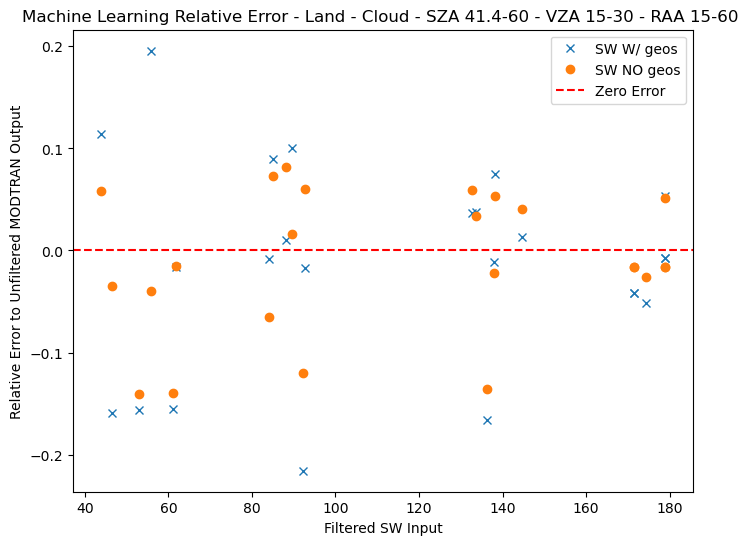

In [7]:
bm_with_geos = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 input_features=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=sw_2nd_best, use_groups=True)

bm_with_geos_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], bm_with_geos['Final_Model'])

bm_no_geos = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 input_features=['Shortwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=sw_2nd_best, use_groups=True)

bm_no_geos_pe = calculate_pe(matt_test_data, ['Shortwave Filtered Rads (Integrated)',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], bm_no_geos['Final_Model'])

display_pe(sw_input, bm_with_geos_pe, bm_no_geos_pe, "SW W/ geos", "SW NO geos")

Using selected VIIRS bands: ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
Index(['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11'],
      dtype='object')
Train (4955, 19), Val (620, 19), Test (620, 19)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']
Using selected VIIRS bands: ['Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
Index(['Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'],
      dtype='object')
Train (4955, 16), Val (620, 16), Test (620, 16)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


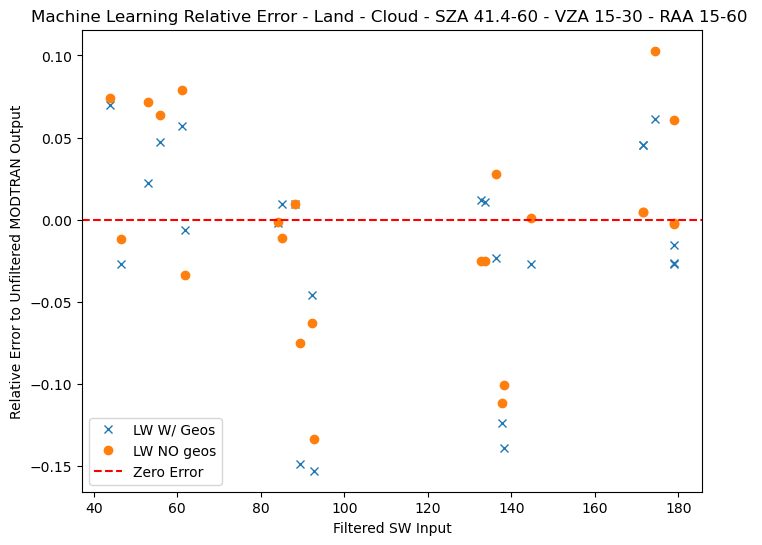

In [22]:
lw_bm_with_geos = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=False,
                                 selected_viirs_bands=['SZA', 'VZA', 'RAZ','Longwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=lw_best, use_groups=True)

lw_bm_with_bands_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ','Longwave Filtered Rads (Integrated)',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], lw_bm_with_geos['Final_Model'], is_sw=False)


lw_bm_no_geos = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=False,
                                 selected_viirs_bands=['Longwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=lw_best, use_groups=True)

lw_bm_no_bands_pe = calculate_pe(matt_test_data, ['Longwave Filtered Rads (Integrated)',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], lw_bm_no_geos['Final_Model'], is_sw=False)

display_pe(sw_input, lw_bm_with_bands_pe, lw_bm_no_bands_pe, "LW W/ Geos", "LW NO geos")

In [23]:
compare_global_vs_bin_fit_interactive(
    land_clear,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=lw_bm_no_geos["Final_Model"],
    name="Land Clear LW",
    ml_features=['Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'],
    is_sw=False
)


For all Land Clear data:
R² Value: 0.9999198417490353
Root Mean Squared Error: 0.0982127335401307
coefficients: [[0.         1.61151387]], intercept: [-2.87341513]

For binned Land Clear data:
R² Value: 0.9999170829757398
Root Mean Squared Error: 0.06857398078970471
coefficients: [[0.         1.62578257]], intercept: [-3.66869268]

ML Model Metrics:
R² Value: 0.9998049039046524
Root Mean Squared Error: 0.15322088673812687
Mean Absolute Percentage Error: 0.11%
Regression line coefficients: [[0.         0.99744234]], intercept: [0.19918016]


In [24]:
compare_global_vs_bin_fit_interactive(
    land_cloudy,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=lw_bm_no_geos["Final_Model"],
    name="Land cloudy LW",
    ml_features=['Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'],
    is_sw=False
)


For all Land Clear data:
R² Value: 0.9999069062111076
Root Mean Squared Error: 0.126964293388733
coefficients: [[0.         1.59684946]], intercept: [-2.28754953]

For binned Land Clear data:
R² Value: 0.9999069237140272
Root Mean Squared Error: 0.12900368120875516
coefficients: [[0.         1.59888505]], intercept: [-2.3905688]

ML Model Metrics:
R² Value: 0.9998691254462401
Root Mean Squared Error: 0.15053894002382961
Mean Absolute Percentage Error: 0.11%
Regression line coefficients: [[0.         0.99996806]], intercept: [-0.0084122]


In [25]:
display_model_metrics(lw_bm_with_geos)


Validation Metrics:
--------------------------------------------------
RMSE:      0.3223014242770507
MAE:       0.15819027312918713
MAPE:      0.2763921050649722%
R²:        0.9996291961984624

Cross-Validation:
--------------------------------------------------
RMSE (mean ± std): 0.40134605654300926 ± 0.13045621342700542
RMSE per fold: ['0.6017030517678122', '0.2722499954874969', '0.2978060610198216', '0.4139446553226179', '0.42102651911729744']

Test Metrics:
--------------------------------------------------
RMSE:      0.3071559546666907
MAE:       0.13854281986565076
MAPE:      0.2607001019831268%
R²:        0.9996664022130317


In [26]:
display_model_metrics(lw_bm_no_geos)


Validation Metrics:
--------------------------------------------------
RMSE:      0.3013308534731558
MAE:       0.14686340636035403
MAPE:      0.2561791412770955%
R²:        0.999675879177834

Cross-Validation:
--------------------------------------------------
RMSE (mean ± std): 0.3820444084498867 ± 0.12449497248312784
RMSE per fold: ['0.573098504851127', '0.2527035171042021', '0.2916223946093491', '0.38699082871707974', '0.4058067969676755']

Test Metrics:
--------------------------------------------------
RMSE:      0.2925145766142661
MAE:       0.1325789785174863
MAPE:      0.2540201960648036%
R²:        0.9996974478049592


In [8]:
test_sw_geos = bm_with_geos["Test_data"]
X_test_sw_geos = test_sw_geos["X_test"]
y_test_sw_geos = test_sw_geos["y_test"]
meta_test_sw_geos = test_sw_geos["meta_test"]
idxs_test_sw_geos = test_sw_geos["idxs"]
test_features = pd.DataFrame(X_test_sw_geos, columns=["SZA", 'VZA', 'RAZ',
       'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'])
test_target = pd.Series(y_test_sw_geos, name="Shortwave Unfiltered Rads (Integrated)")
test_sw_geos_ds = pd.concat([test_features, test_target], axis=1)

test_sw_no_geos = bm_no_geos["Test_data"]
X_test_sw_no_geos = test_sw_no_geos["X_test"]
y_test_sw_no_geos = test_sw_no_geos["y_test"]
meta_test_sw_no_geos = test_sw_no_geos["meta_test"]
idxs_test_sw_no_geos = test_sw_no_geos["idxs"]
test_features = pd.DataFrame(X_test_sw_no_geos, columns=[
       'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'])
test_target = pd.Series(y_test_sw_no_geos, name="Shortwave Unfiltered Rads (Integrated)")
geos = meta_test_sw_no_geos[["SZA", "VZA", "RAZ"]]
test_sw_no_geos_ds = pd.concat(
    [
        geos.reset_index(drop=True),
        test_features.reset_index(drop=True),
        test_target.reset_index(drop=True)
    ],
    axis=1
)

test_lw_geos = lw_bm_with_geos["Test_data"]
X_test_lw_geos = test_lw_geos["X_test"]
y_test_lw_geos = test_lw_geos["y_test"]
meta_test_lw_geos = test_lw_geos["meta_test"]
idxs_test_lw_geos = test_lw_geos["idxs"]
test_features = pd.DataFrame(X_test_lw_geos, columns=["SZA", 'VZA', 'RAZ',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'])
test_target = pd.Series(y_test_lw_geos, name="Longwave Unfiltered Rads (Integrated)")
test_lw_geos_ds = pd.concat([test_features, test_target], axis=1)

test_lw_no_geos = lw_bm_no_geos["Test_data"]
X_test_lw_no_geos = test_lw_no_geos["X_test"]
y_test_lw_no_geos = test_lw_no_geos["y_test"]
meta_test_lw_no_geos = test_lw_no_geos["meta_test"]
idxs_test_lw_no_geos = test_lw_no_geos["idxs"]
test_features = pd.DataFrame(X_test_lw_no_geos, columns=[
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'])
test_target = pd.Series(y_test_lw_no_geos, name="Longwave Unfiltered Rads (Integrated)")
geos = meta_test_lw_no_geos[["SZA", "VZA", "RAZ"]]
# test_lw_no_geos_ds = pd.concat([geos, test_features, test_target], axis=1)
test_lw_no_geos_ds = pd.concat(
    [
        geos.reset_index(drop=True),
        test_features.reset_index(drop=True),
        test_target.reset_index(drop=True)
    ],
    axis=1
)

NameError: name 'lw_bm_with_geos' is not defined

In [29]:
np.shape(geos), np.shape(meta_test_lw_no_geos), np.shape(X_test_lw_no_geos), np.shape(y_test_lw_no_geos)

((620, 3), (620, 21), (620, 16), (620,))

In [30]:
np.nan in geos, np.nan in meta_test_lw_no_geos, np.nan in X_test_lw_no_geos, np.nan in y_test_lw_no_geos

(False, False, False, False)

In [31]:
test_sw_geos_ds

,SZA,VZA,RAZ,Shortwave Filtered Rads (Integrated),M1,M2,M3,M4,I1,M5,DNB,M6,I2,M7,M8,M9,I3,M10,M11,Shortwave Unfiltered Rads (Integrated)
0,0.000,0.000,0.0,205.100385,21.350814,24.215420,25.906300,22.593355,70.298263,18.116427,274.098117,12.941787,18.541671,18.541671,1.537920,0.008377,0.195583,0.195583,0.070352,284.609397
1,0.311,30.000,37.5,201.710600,20.721059,23.434325,24.964077,21.619696,67.745736,17.492056,268.190576,12.736542,18.450208,18.450208,1.598262,0.008599,0.126958,0.126958,0.043847,279.532816
2,0.311,30.000,37.5,173.698838,19.761074,22.590733,24.181493,20.819755,63.261407,16.081888,237.978049,11.114626,14.046980,14.046980,0.429904,0.031909,0.078145,0.078145,0.020246,242.422908
3,0.311,30.000,37.5,213.262543,19.983682,22.788572,24.370129,20.931569,63.101068,16.193503,254.983161,11.386424,16.828750,16.828750,3.413996,0.017293,5.161575,5.161575,1.119413,291.450253
4,0.511,30.000,142.5,201.757040,20.636867,23.400767,25.004488,21.701706,68.037906,17.598571,268.036991,12.794587,18.497068,18.497068,1.587921,0.035328,0.178039,0.178039,0.057300,279.449325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615,84.849,45.000,142.5,4.524490,0.887184,0.901587,0.806500,0.487258,1.176341,0.290578,6.541508,0.180806,0.196859,0.196859,0.020526,0.002180,0.019908,0.019908,0.002110,6.703173
616,84.852,60.000,7.5,15.941029,1.410101,1.610705,1.721181,1.363196,4.504269,1.300039,19.108414,0.971646,1.551589,1.551589,0.360835,0.010632,0.539130,0.539130,0.089091,21.651975
617,84.848,60.000,172.5,7.687076,1.465568,1.502808,1.357491,0.828149,2.025455,0.505112,11.033873,0.316273,0.356049,0.356049,0.039013,0.003552,0.036009,0.036009,0.004008,11.320198
618,85.648,89.947,37.5,19.949918,2.338283,2.809726,3.047577,2.030956,6.531766,1.982956,26.820217,1.390422,1.648981,1.648981,0.117572,0.010867,0.065167,0.065167,0.003139,27.528811


In [32]:
test_sw_no_geos_ds

,SZA,VZA,RAZ,Shortwave Filtered Rads (Integrated),M1,M2,M3,M4,I1,M5,DNB,M6,I2,M7,M8,M9,I3,M10,M11,Shortwave Unfiltered Rads (Integrated)
0,0.000,0.000,0.0,205.100385,21.350814,24.215420,25.906300,22.593355,70.298263,18.116427,274.098117,12.941787,18.541671,18.541671,1.537920,0.008377,0.195583,0.195583,0.070352,284.609397
1,0.311,30.000,37.5,201.710600,20.721059,23.434325,24.964077,21.619696,67.745736,17.492056,268.190576,12.736542,18.450208,18.450208,1.598262,0.008599,0.126958,0.126958,0.043847,279.532816
2,0.311,30.000,37.5,173.698838,19.761074,22.590733,24.181493,20.819755,63.261407,16.081888,237.978049,11.114626,14.046980,14.046980,0.429904,0.031909,0.078145,0.078145,0.020246,242.422908
3,0.311,30.000,37.5,213.262543,19.983682,22.788572,24.370129,20.931569,63.101068,16.193503,254.983161,11.386424,16.828750,16.828750,3.413996,0.017293,5.161575,5.161575,1.119413,291.450253
4,0.511,30.000,142.5,201.757040,20.636867,23.400767,25.004488,21.701706,68.037906,17.598571,268.036991,12.794587,18.497068,18.497068,1.587921,0.035328,0.178039,0.178039,0.057300,279.449325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615,84.849,45.000,142.5,4.524490,0.887184,0.901587,0.806500,0.487258,1.176341,0.290578,6.541508,0.180806,0.196859,0.196859,0.020526,0.002180,0.019908,0.019908,0.002110,6.703173
616,84.852,60.000,7.5,15.941029,1.410101,1.610705,1.721181,1.363196,4.504269,1.300039,19.108414,0.971646,1.551589,1.551589,0.360835,0.010632,0.539130,0.539130,0.089091,21.651975
617,84.848,60.000,172.5,7.687076,1.465568,1.502808,1.357491,0.828149,2.025455,0.505112,11.033873,0.316273,0.356049,0.356049,0.039013,0.003552,0.036009,0.036009,0.004008,11.320198
618,85.648,89.947,37.5,19.949918,2.338283,2.809726,3.047577,2.030956,6.531766,1.982956,26.820217,1.390422,1.648981,1.648981,0.117572,0.010867,0.065167,0.065167,0.003139,27.528811


In [33]:
test_lw_geos_ds

,SZA,VZA,RAZ,Longwave Filtered Rads (Integrated),M1,M2,M3,M4,I1,M5,DNB,M6,I2,M7,M8,M9,I3,M10,M11,Longwave Unfiltered Rads (Integrated)
0,0.000,0.000,0.0,42.442496,21.350814,24.215420,25.906300,22.593355,70.298263,18.116427,274.098117,12.941787,18.541671,18.541671,1.537920,0.008377,0.195583,0.195583,0.070352,65.402706
1,0.311,30.000,37.5,42.445827,20.721059,23.434325,24.964077,21.619696,67.745736,17.492056,268.190576,12.736542,18.450208,18.450208,1.598262,0.008599,0.126958,0.126958,0.043847,65.430985
2,0.311,30.000,37.5,42.824308,19.761074,22.590733,24.181493,20.819755,63.261407,16.081888,237.978049,11.114626,14.046980,14.046980,0.429904,0.031909,0.078145,0.078145,0.020246,66.148467
3,0.311,30.000,37.5,41.127891,19.983682,22.788572,24.370129,20.931569,63.101068,16.193503,254.983161,11.386424,16.828750,16.828750,3.413996,0.017293,5.161575,5.161575,1.119413,63.268437
4,0.511,30.000,142.5,40.160330,20.636867,23.400767,25.004488,21.701706,68.037906,17.598571,268.036991,12.794587,18.497068,18.497068,1.587921,0.035328,0.178039,0.178039,0.057300,61.816938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615,84.849,45.000,142.5,59.294182,0.887184,0.901587,0.806500,0.487258,1.176341,0.290578,6.541508,0.180806,0.196859,0.196859,0.020526,0.002180,0.019908,0.019908,0.002110,92.799862
616,84.852,60.000,7.5,58.423041,1.410101,1.610705,1.721181,1.363196,4.504269,1.300039,19.108414,0.971646,1.551589,1.551589,0.360835,0.010632,0.539130,0.539130,0.089091,91.598226
617,84.848,60.000,172.5,57.134301,1.465568,1.502808,1.357491,0.828149,2.025455,0.505112,11.033873,0.316273,0.356049,0.356049,0.039013,0.003552,0.036009,0.036009,0.004008,89.326754
618,85.648,89.947,37.5,44.628441,2.338283,2.809726,3.047577,2.030956,6.531766,1.982956,26.820217,1.390422,1.648981,1.648981,0.117572,0.010867,0.065167,0.065167,0.003139,69.094287


In [34]:
test_lw_no_geos_ds

,SZA,VZA,RAZ,Longwave Filtered Rads (Integrated),M1,M2,M3,M4,I1,M5,DNB,M6,I2,M7,M8,M9,I3,M10,M11,Longwave Unfiltered Rads (Integrated)
0,0.000,0.000,0.0,42.442496,21.350814,24.215420,25.906300,22.593355,70.298263,18.116427,274.098117,12.941787,18.541671,18.541671,1.537920,0.008377,0.195583,0.195583,0.070352,65.402706
1,0.311,30.000,37.5,42.445827,20.721059,23.434325,24.964077,21.619696,67.745736,17.492056,268.190576,12.736542,18.450208,18.450208,1.598262,0.008599,0.126958,0.126958,0.043847,65.430985
2,0.311,30.000,37.5,42.824308,19.761074,22.590733,24.181493,20.819755,63.261407,16.081888,237.978049,11.114626,14.046980,14.046980,0.429904,0.031909,0.078145,0.078145,0.020246,66.148467
3,0.311,30.000,37.5,41.127891,19.983682,22.788572,24.370129,20.931569,63.101068,16.193503,254.983161,11.386424,16.828750,16.828750,3.413996,0.017293,5.161575,5.161575,1.119413,63.268437
4,0.511,30.000,142.5,40.160330,20.636867,23.400767,25.004488,21.701706,68.037906,17.598571,268.036991,12.794587,18.497068,18.497068,1.587921,0.035328,0.178039,0.178039,0.057300,61.816938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615,84.849,45.000,142.5,59.294182,0.887184,0.901587,0.806500,0.487258,1.176341,0.290578,6.541508,0.180806,0.196859,0.196859,0.020526,0.002180,0.019908,0.019908,0.002110,92.799862
616,84.852,60.000,7.5,58.423041,1.410101,1.610705,1.721181,1.363196,4.504269,1.300039,19.108414,0.971646,1.551589,1.551589,0.360835,0.010632,0.539130,0.539130,0.089091,91.598226
617,84.848,60.000,172.5,57.134301,1.465568,1.502808,1.357491,0.828149,2.025455,0.505112,11.033873,0.316273,0.356049,0.356049,0.039013,0.003552,0.036009,0.036009,0.004008,89.326754
618,85.648,89.947,37.5,44.628441,2.338283,2.809726,3.047577,2.030956,6.531766,1.982956,26.820217,1.390422,1.648981,1.648981,0.117572,0.010867,0.065167,0.065167,0.003139,69.094287


In [35]:
test_lw_no_geos_ds
has_nan_in_column = test_lw_no_geos_ds.isnull().any()

# Get the names of columns that have NaN values
columns_with_nan = has_nan_in_column[has_nan_in_column].index.tolist()
columns_with_nan

[]

In [36]:
compare_global_vs_bin_fit_interactive(
    test_lw_geos_ds,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=lw_bm_with_geos["Final_Model"],
    name="Unseen Data LW W/ Geos",
    ml_features=["SZA", 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'],
    is_sw=False
)


For all Land Clear data:
R² Value: 0.9997803861409308
Root Mean Squared Error: 0.24921675131030804
coefficients: [[0.         1.59257595]], intercept: [-2.00459362]

For binned Land Clear data:
R² Value: 0.9999224931995996
Root Mean Squared Error: 0.10884591212539578
coefficients: [[0.         1.60876336]], intercept: [-2.83010278]

ML Model Metrics:
R² Value: 0.9996664022130317
Root Mean Squared Error: 0.3071559546666907
Mean Absolute Percentage Error: 0.26%
Regression line coefficients: [[0.        0.9972332]], intercept: [0.18084307]


In [37]:
compare_global_vs_bin_fit_interactive(
    test_lw_no_geos_ds,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=lw_bm_no_geos["Final_Model"],
    name="Unseen Data LW",
    ml_features=['Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11'],
    is_sw=False
)


For all Land Clear data:
R² Value: 0.9997803861409308
Root Mean Squared Error: 0.24921675131030804
coefficients: [[0.         1.59257595]], intercept: [-2.00459362]

For binned Land Clear data:
R² Value: 0.9999224931995996
Root Mean Squared Error: 0.10884591212539578
coefficients: [[0.         1.60876336]], intercept: [-2.83010278]

ML Model Metrics:
R² Value: 0.9996974478049592
Root Mean Squared Error: 0.2925145766142661
Mean Absolute Percentage Error: 0.25%
Regression line coefficients: [[0.        0.9977353]], intercept: [0.15106779]


Input features ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)']
In train test split: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)']
Train (4950, 4), Val (610, 4), Test (635, 4)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']
In calc pe ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)']
df cols: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Shortwave Unfiltered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Longwave Unfiltered Rads (Integrated)']


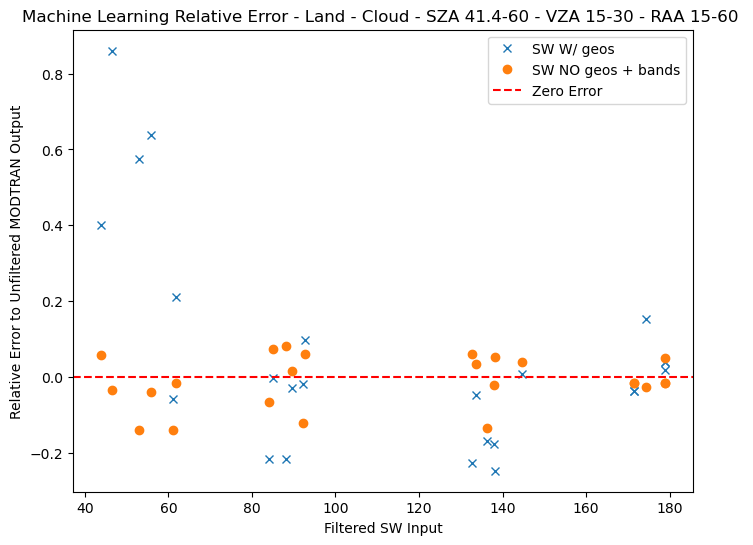

In [12]:
sw_with_geos = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True, input_features=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)'],  best_params=sw_2nd_best, use_groups=True)

sw_with_geos_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)'], sw_with_geos['Final_Model'])

# sw_no_geos = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
#                                  selected_viirs_bands=['Shortwave Filtered Rads (Integrated)',
#                                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
#                                                        'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=sw_2nd_best, use_groups=True)

# bm_no_geos_pe = calculate_pe(matt_test_data, ['Shortwave Filtered Rads (Integrated)',
#                                         'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
#                                         'M8', 'M9', 'I3', 'M10', 'M11'], bm_no_geos['Final_Model'])

display_pe(sw_input, sw_with_geos_pe, bm_no_geos_pe, "SW W/ geos", "SW NO geos + bands")

In [18]:
display_model_metrics(sw_with_geos)


Validation Metrics:
--------------------------------------------------
RMSE:      0.8664680502147426
MAE:       0.4929318642017383
MAPE:      0.8658469193589755%
R²:        0.9999046556192391

Cross-Validation:
--------------------------------------------------
RMSE (mean ± std): 1.8110804409744543 ± 0.600153731961305
RMSE per fold: ['1.2392553178613077', '1.135067806879728', '2.3588174670671496', '2.397429969101866', '1.924831643962219']

Test Metrics:
--------------------------------------------------
RMSE:      1.0685860230190392
MAE:       0.5093173498908767
MAPE:      0.6707691901967398%
R²:        0.9998640970020598


In [19]:
compare_global_vs_bin_fit_interactive(
    land_clear,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=sw_with_geos["Final_Model"],
    name="Land Clear SW W/ Geos",
    ml_features=['Shortwave Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ'],
    is_sw=True
)


For all Land Clear data:
R² Value: 0.9985709354453441
Root Mean Squared Error: 1.3450740616975378
coefficients: [[0.        1.3295314]], intercept: [1.82385475]

For binned Land Clear data:
R² Value: 0.9990591266696384
Root Mean Squared Error: 0.4462393025696642
coefficients: [[0.         1.29265294]], intercept: [3.28797064]

ML Model Metrics:
R² Value: -8.998672697087866
Root Mean Squared Error: 112.51008433018086
Mean Absolute Percentage Error: 330.21%
Regression line coefficients: [[ 0.         -0.33755864]], intercept: [138.94530679]


In [ ]:
compare_global_vs_bin_fit_interactive(
    land_clear,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=sw_with_geos["Final_Model"],
    name="Land Clear SW W/ Geos",
    ml_features=['Shortwave Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ'],
    is_sw=True
)

In [102]:
all_dataset.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)',
       'Split Shortwave Filtered Rads (Integrated)',
       'Total Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5',
       'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12',
       'M13', 'M14', 'M15', 'I5', 'M16', 'Scaled Shortwave Filtered',
       'Scaled Shortwave Unfiltered', 'Scaled Longwave Filtered',
       'Scaled Longwave Unfiltered'],
      dtype='object')

In [13]:
ssw_model = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 input_features=['SZA', 'VZA', 'RAZ', "Split Shortwave Filtered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)"],  best_params=sw_2nd_best, use_groups=True)

ssw_model_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ', "Split Shortwave Filtered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)"], ssw_model['Final_Model'], is_sw=True)

Input features ['SZA', 'VZA', 'RAZ', 'Split Shortwave Filtered Rads (Integrated)', 'Shortwave Filtered Rads (Integrated)']
In train test split: ['SZA', 'VZA', 'RAZ', 'Split Shortwave Filtered Rads (Integrated)', 'Shortwave Filtered Rads (Integrated)']
Train (4950, 5), Val (610, 5), Test (635, 5)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']
In calc pe ['SZA', 'VZA', 'RAZ', 'Split Shortwave Filtered Rads (Integrated)', 'Shortwave Filtered Rads (Integrated)']
df cols: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'Split Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Shortwave Unfiltered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)', 'Longwave Unfiltered Rads (Integrated)']


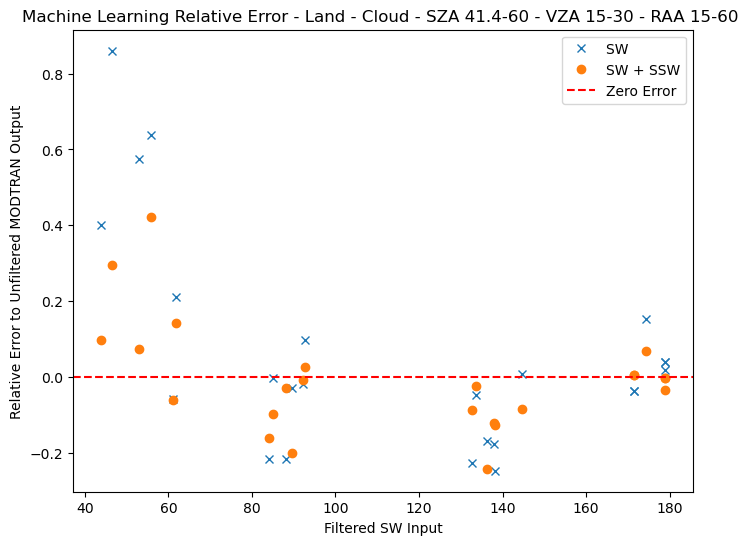

In [14]:
# sw_model = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
#                                  selected_viirs_bands=['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)'],  best_params=sw_2nd_best, use_groups=True)
#
# sw_model_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ','Shortwave Filtered Rads (Integrated)'], sw_model['Final_Model'], is_sw=True)

display_pe(sw_input, sw_with_geos_pe, ssw_model_pe, "SW ", "SW + SSW")

In [16]:
test_sw_geos_no_bands = sw_with_geos["Test_data"]
X_test_sw_geos_no_bands = test_sw_geos_no_bands["X_test"]
y_test_sw_geos_no_bands = test_sw_geos_no_bands["y_test"]
meta_test_sw_geos_no_bands = test_sw_geos_no_bands["meta_test"]
idxs_test_sw_geos_no_bands = test_sw_geos_no_bands["idxs"]
test_features = pd.DataFrame(X_test_sw_geos_no_bands, columns=["SZA", 'VZA', 'RAZ',
       'Shortwave Filtered Rads (Integrated)'])
test_target = pd.Series(y_test_sw_geos_no_bands, name="Shortwave Unfiltered Rads (Integrated)")
test_sw_geos_no_bands_ds = pd.concat([test_features, test_target], axis=1)

test_ssw = ssw_model["Test_data"]
X_test_ssw = test_ssw["X_test"]
y_test_ssw = test_ssw["y_test"]
meta_test_ssw = test_ssw["meta_test"]
idxs_test_ssw = test_ssw["idxs"]
test_features["Split Shortwave Filtered Rads (Integrated)"] = X_test_ssw[:, -1]
test_target = pd.Series(y_test_ssw, name="Shortwave Unfiltered Rads (Integrated)")
test_ssw_ds = pd.concat(
    [
        test_features,
        test_target
    ],
    axis=1
)

In [9]:
t1 = test_sw_geos_no_bands_ds[["SZA", 'VZA', 'RAZ']]
t2 = test_ssw_ds[["SZA", 'VZA', 'RAZ']]
np.array_equal(t1, t2)

NameError: name 'test_sw_geos_no_bands_ds' is not defined

In [96]:
test_ssw_ds

,SZA,VZA,RAZ,Shortwave Filtered Rads (Integrated),Split Shortwave Filtered Rads (Integrated),Shortwave Unfiltered Rads (Integrated)
0,0.000,0.000,0.0,205.100385,43.902177,284.609397
1,0.311,30.000,37.5,201.710600,45.029454,279.532816
2,0.311,30.000,37.5,173.698838,30.073598,242.422908
3,0.311,30.000,37.5,213.262543,58.739905,291.450253
4,0.511,30.000,142.5,201.757040,44.910014,279.449325
...,...,...,...,...,...,...
615,84.849,45.000,142.5,4.524490,0.516848,6.703173
616,84.852,60.000,7.5,15.941029,4.761436,21.651975
617,84.848,60.000,172.5,7.687076,0.924378,11.320198
618,85.648,89.947,37.5,19.949918,3.684914,27.528811


In [29]:
test_sw_geos_no_bands_ds

,SZA,VZA,RAZ,Shortwave Filtered Rads (Integrated),Shortwave Unfiltered Rads (Integrated)
0,0.000,0.000,0.0,271.728794,367.808738
1,0.000,0.000,0.0,204.108679,283.160785
2,0.066,30.000,7.5,233.014755,318.335206
3,0.066,30.000,7.5,173.678635,242.573267
4,0.311,30.000,37.5,220.420955,303.613736
...,...,...,...,...,...
630,84.848,60.000,172.5,7.192588,10.673827
631,85.850,89.947,7.5,154.145855,198.342393
632,85.648,89.947,37.5,43.106074,57.066929
633,84.911,89.947,90.0,24.265128,33.474285


In [55]:
compare_global_vs_bin_fit_interactive(
    test_sw_geos_no_bands_ds,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=sw_with_geos["Final_Model"],
    name="Unseen SW + Geos no bands",
    ml_features=['Shortwave Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ'],
    is_sw=True
)


METRICS FOR: Unseen SW + Geos no bands

Land - Global Fit (all data):
  R² Value: 0.9987
  RMSE: 3.2490
  Coefficients: [[0.       1.339892]]
  Intercept: [2.2029675]

Land - Binned Fit:
  R² Value: 1.0000
  RMSE: 0.4086
  Coefficients: [[0.         1.34647339]]
  Intercept: [2.08039235]



In [17]:
plot_ml_predictions(df=test_sw_geos_no_bands_ds, ml_model=sw_with_geos['Final_Model'], ml_features=['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)'], scene=None, is_sw=True, name="All Scenes")


All Scenes ML Model Metrics:
R² Value: 0.9999
Root Mean Squared Error: 1.0686
Mean Absolute Percentage Error: 0.67%
Regression line: y = 0.9981x + 0.1323


In [18]:
plot_ml_predictions(df=test_ssw_ds, ml_model=ssw_model['Final_Model'], ml_features=['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', "Split Shortwave Filtered Rads (Integrated)"], scene=None, is_sw=True, name="All Scenes")


All Scenes ML Model Metrics:
R² Value: 0.8201
Root Mean Squared Error: 38.8761
Mean Absolute Percentage Error: 48.60%
Regression line: y = 1.0933x + 25.0207


In [58]:
compare_global_vs_bin_fit_interactive(
    test_ssw_ds,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1,
    ml_model=ssw_model["Final_Model"],
    name="Unseen SSW + Geos no bands",
    ml_features=["Split Shortwave Filtered Rads (Integrated)", 'Shortwave Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ'],
    is_sw=True
)


METRICS FOR: Unseen SSW + Geos no bands

Land - Global Fit (all data):
  R² Value: 0.9987
  RMSE: 3.2490
  Coefficients: [[0.       1.339892]]
  Intercept: [2.2029675]

Land - Binned Fit:
  R² Value: 1.0000
  RMSE: 0.4086
  Coefficients: [[0.         1.34647339]]
  Intercept: [2.08039235]



In [64]:
compare_global_vs_bin_fit_interactive(
    test_sw_geos_no_bands_ds,
    scene="Land",
    sza_range=(40,60),
    vza_range=(15,60),
    raz_range=(15,60),
    degree=1,
    ml_model=sw_with_geos["Final_Model"],
    name="Land Scene",
    ml_features=['Shortwave Filtered Rads (Integrated)', 'SZA', 'VZA', 'RAZ'],
    is_sw=True
)


METRICS FOR: Land Scene

Land - Global Fit (all data):
  R² Value: 0.9987
  RMSE: 3.2490
  Coefficients: [[0.       1.339892]]
  Intercept: [2.2029675]

Land - Binned Fit:
  R² Value: 0.9998
  RMSE: 1.1887
  Coefficients: [[0.         1.34846306]]
  Intercept: [2.50394825]

ML Model (all data):
  R² Value: -0.8986
  RMSE: 126.3040
  MAPE: 210.42%
  Regression line: y = -0.1350x + 127.6386

ML Model (binned data):
  R² Value: -1.2114
  RMSE: 117.2722
  MAPE: 95.91%
  Regression line: y = -0.0074x + 53.6364

